# Sprint 1 - Data Understanding & Exploratory Data Analysis

**Project:** AutoGuard AI - Insurance Underwriting Assistant  
**Scope:** Data understanding only  
**Dataset source:** `data/raw/train.csv`, `data/raw/test.csv`, `data/raw/sample_submission.csv`  
**Target variable:** `is_claim`

This notebook is limited to Sprint 1 deliverables. It does **not** train models, perform feature engineering, build preprocessing pipelines, or touch backend/frontend work.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from ml_pipeline import data_analyst as da

plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)

In [2]:
train_df = da.load_train_data()
test_df = da.load_test_data()
sample_submission_df = da.load_sample_submission()

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print('Sample submission shape:', sample_submission_df.shape)

Train shape: (58592, 44)
Test shape: (39063, 43)
Sample submission shape: (39063, 2)


## Phase 1 - Dataset Overview

In [3]:
overview = da.data_overview(train_df, test_df)
overview_table = pd.DataFrame([
    {'metric': 'Train rows', 'value': overview['train_rows']},
    {'metric': 'Train columns', 'value': overview['train_columns']},
    {'metric': 'Test rows', 'value': overview['test_rows']},
    {'metric': 'Test columns', 'value': overview['test_columns']},
    {'metric': 'Train size (bytes)', 'value': overview['train_size_bytes']},
    {'metric': 'Train size (MiB)', 'value': round(overview['train_size_bytes'] / (1024 * 1024), 2)},
    {'metric': 'Numerical feature count', 'value': overview['numerical_feature_count']},
    {'metric': 'Categorical feature count', 'value': overview['categorical_feature_count']},
    {'metric': 'Binary feature count', 'value': overview['binary_feature_count']},
])

dtype_table = pd.DataFrame({'column': train_df.columns, 'dtype': train_df.dtypes.astype(str).values})
inventory = da.feature_inventory()
inventory_table = pd.DataFrame([
    {'group': key, 'count': len(value), 'columns': ', '.join(map(str, value))}
    for key, value in inventory.items()
])
schema_parity = pd.DataFrame([da.schema_parity_summary(train_df, test_df)])
data_dictionary = da.build_data_dictionary(train_df)

display(overview_table)
display(dtype_table)
display(inventory_table)
display(schema_parity)
display(data_dictionary)

,metric,value
0,Train rows,58592.00
1,Train columns,44.00
2,Test rows,39063.00
3,Test columns,43.00
4,Train size (bytes),95070212.00
5,Train size (MiB),90.67
6,Numerical feature count,14.00
7,Categorical feature count,9.00
8,Binary feature count,19.00


,column,dtype
0,policy_id,str
1,policy_tenure,float64
2,age_of_car,float64
3,age_of_policyholder,float64
4,area_cluster,str
5,population_density,int64
6,make,int64
7,segment,str
8,model,str
9,fuel_type,str


,group,count,columns
0,identifier,1,policy_id
1,target,1,is_claim
2,numerical,14,"policy_tenure, age_of_car, age_of_policyholder..."
3,categorical,9,"area_cluster, make, segment, model, fuel_type,..."
4,binary,19,"is_esc, is_adjustable_steering, is_tpms, is_pa..."


,train_only_columns,test_only_columns,feature_order_matches,train_feature_count,test_feature_count
0,[is_claim],[],True,43,43


,column_name,role,dtype,business_meaning,unique_values,example_values
0,policy_id,identifier,str,Unique policy identifier used for record trace...,58592,"ID00001, ID00002, ID00003, ID00004, ID00005"
1,policy_tenure,numerical,float64,Normalized duration of the policy at observati...,58592,"0.515873589958172, 0.672618513547733, 0.841110..."
2,age_of_car,numerical,float64,Normalized age of the insured vehicle.,49,"0.05, 0.02, 0.11, 0.07, 0.16"
3,age_of_policyholder,numerical,float64,Normalized age of the policyholder.,75,"0.644230769230769, 0.375, 0.384615384615385, 0..."
4,area_cluster,categorical,str,Geographic or operational cluster code for the...,22,"C1, C2, C3, C4, C5"
5,population_density,numerical,int64,Population density associated with the policy ...,22,"4990, 27003, 4076, 21622, 34738"
6,make,categorical,int64,Encoded vehicle manufacturer or make category.,5,"1, 2, 3, 4, 5"
7,segment,categorical,str,Vehicle market segment code.,6,"A, C1, C2, B2, B1"
8,model,categorical,str,Vehicle model code.,11,"M1, M2, M3, M4, M5"
9,fuel_type,categorical,str,Primary fuel type of the vehicle.,3,"CNG, Petrol, Diesel"


### Dataset Overview Interpretation

- The labeled training table contains **58,592 rows** and **44 columns**.
- The official test table contains **39,063 rows** and **43 columns**.
- The training dataset occupies about **90.67 MiB** in memory.
- The active feature inventory is **14 numerical features**, **9 non-binary categorical features**, and **19 binary features**, plus one identifier and one target.
- Train/test schema parity is clean: the only train-only column is the target `is_claim`, and the feature order matches the official test set.


## Phase 2 - Data Quality Assessment

C:\Users\97252\AppData\Local\Temp\ipykernel_13360\2498742538.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(missing_table['column'], rotation=90)


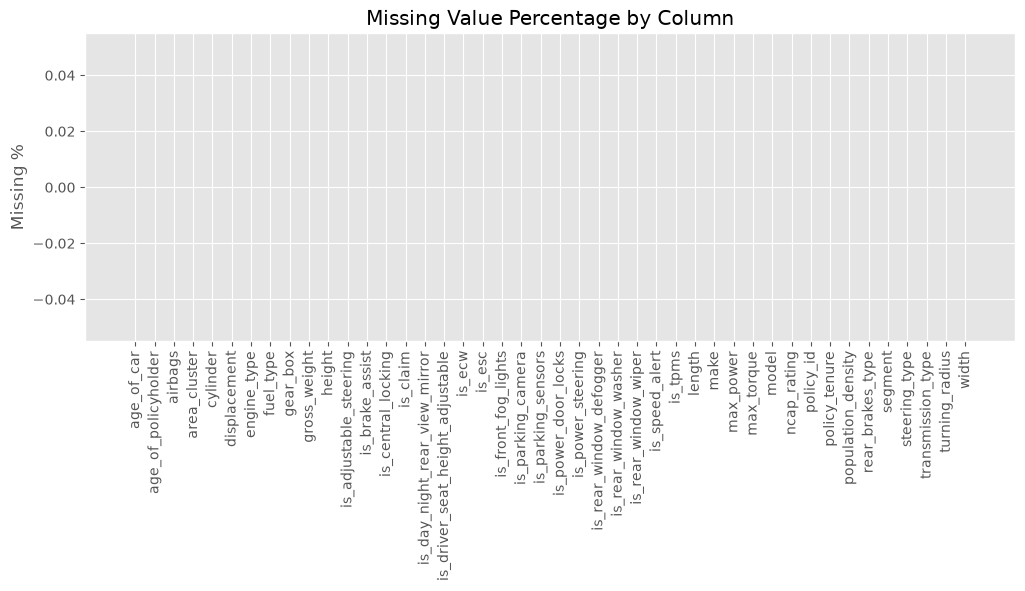

,column,missing_count,missing_percentage
0,age_of_car,0,0.0
1,age_of_policyholder,0,0.0
2,airbags,0,0.0
3,area_cluster,0,0.0
4,cylinder,0,0.0
5,displacement,0,0.0
6,engine_type,0,0.0
7,fuel_type,0,0.0
8,gear_box,0,0.0
9,gross_weight,0,0.0


,check,value
0,Full duplicates,0
1,Duplicates excluding policy_id,0


,column,min,max,invalid_count
0,policy_tenure,0.002735,1.396641,0
1,age_of_car,0.000000,1.000000,0
2,age_of_policyholder,0.288462,1.000000,0
3,population_density,290.000000,73430.000000,0
4,airbags,1.000000,6.000000,0
5,displacement,796.000000,1498.000000,0
6,cylinder,3.000000,4.000000,0
7,gear_box,5.000000,6.000000,0
8,turning_radius,4.500000,5.200000,0
9,length,3445.000000,4300.000000,0


,column,train_unique,test_unique,unexpected_test_values,train_only_values
0,area_cluster,22,22,,
1,make,5,5,,
2,segment,6,6,,
3,model,11,11,,
4,fuel_type,3,3,,
5,max_torque,9,9,,
6,max_power,9,9,,
7,engine_type,11,11,,
8,steering_type,3,3,,
9,is_esc,2,2,,


,column,observed_values,invalid_values,invalid_count
0,is_esc,"No, Yes",,0
1,is_adjustable_steering,"No, Yes",,0
2,is_tpms,"No, Yes",,0
3,is_parking_sensors,"No, Yes",,0
4,is_parking_camera,"No, Yes",,0
5,is_front_fog_lights,"No, Yes",,0
6,is_rear_window_wiper,"No, Yes",,0
7,is_rear_window_washer,"No, Yes",,0
8,is_rear_window_defogger,"No, Yes",,0
9,is_brake_assist,"No, Yes",,0


,column,unique_values,pattern_failures
0,max_torque,9,0
1,max_power,9,0


In [4]:
missing_table = da.missing_value_table(train_df)
duplicate_info = da.duplicate_summary(train_df)
range_table = da.numerical_range_table(train_df)
category_validation = da.validate_categorical_values(train_df, test_df)
yes_no_validation = da.validate_yes_no_columns(train_df)
compound_validation = da.compound_string_pattern_table(train_df)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(missing_table['column'], missing_table['missing_percentage'])
ax.set_title('Missing Value Percentage by Column')
ax.set_ylabel('Missing %')
ax.set_xticklabels(missing_table['column'], rotation=90)
plt.show()

display(missing_table)
display(pd.DataFrame([
    {'check': 'Full duplicates', 'value': duplicate_info.full_duplicates},
    {'check': 'Duplicates excluding policy_id', 'value': duplicate_info.duplicates_excluding_policy_id},
]))
display(range_table)
display(category_validation)
display(yes_no_validation)
display(compound_validation)

### Data Quality Interpretation

- Missing-value analysis shows **0 missing values in every training column**.
- Duplicate analysis shows **0 full duplicates** and **0 duplicates after excluding `policy_id`**.
- The defined numerical range checks found no invalid values in the core numerical columns.
- Yes/No validation found no unexpected values outside `Yes` and `No`.
- Category parity between training and official test data is clean: no unseen test-time categories were detected in the audited categorical fields.
- The compound specification strings `max_torque` and `max_power` match their expected raw patterns across the training data.

Overall, the raw dataset looks structurally strong for later modeling work, with the main remaining work deferred to Sprint 2: parsing compound strings, encoding mixed feature types, and handling class imbalance.


## Phase 3 - Target Variable Analysis

,class,count,percentage
0,0,54844,93.6032
1,1,3748,6.3968


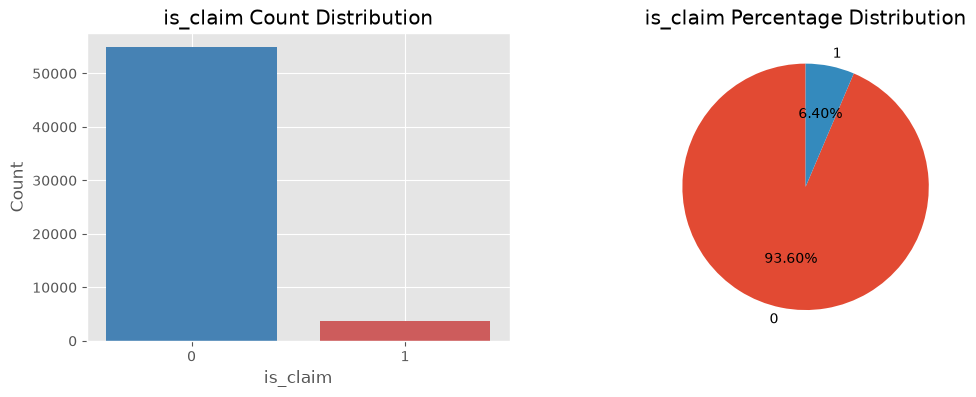

In [5]:
target_distribution = da.target_distribution(train_df)
display(target_distribution)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(target_distribution['class'], target_distribution['count'], color=['steelblue', 'indianred'])
axes[0].set_title('is_claim Count Distribution')
axes[0].set_xlabel('is_claim')
axes[0].set_ylabel('Count')

axes[1].pie(target_distribution['count'], labels=target_distribution['class'], autopct='%1.2f%%', startangle=90)
axes[1].set_title('is_claim Percentage Distribution')
plt.show()

### Target Interpretation

- Non-claim class (`0`): **54,844 rows** (**93.6032%**)
- Claim class (`1`): **3,748 rows** (**6.3968%**)
- Class imbalance ratio: **14.63:1**

**Business implications:** the claim class is rare, which matches a realistic underwriting screening problem where most policies do not generate claims.

**Modeling implications:** the minority class is small enough that naive modeling can ignore it and still appear strong on headline accuracy.

**Evaluation implications:** a majority-class predictor would already achieve about **93.60% accuracy**, so accuracy alone is not a sufficient primary metric. Later modeling should emphasize precision, recall, F1, ROC-AUC, and PR-AUC.


## Phase 4 - Numerical Feature Analysis

In [6]:
numeric_stats = da.numerical_summary_statistics(train_df).round(4)
display(numeric_stats)

,mean,median,std,min,25%,50%,75%,max,skewness
policy_tenure,0.6112,0.5738,0.4142,0.0027,0.2102,0.5738,1.0391,1.3966,0.0536
age_of_car,0.0694,0.0600,0.0567,0.0000,0.0200,0.0600,0.1100,1.0000,1.0941
age_of_policyholder,0.4694,0.4519,0.1229,0.2885,0.3654,0.4519,0.5481,1.0000,0.6400
population_density,18826.8587,8794.0000,17660.1748,290.0000,6112.0000,8794.0000,27003.0000,73430.0000,1.6742
airbags,3.1371,2.0000,1.8326,1.0000,2.0000,2.0000,6.0000,6.0000,0.9059
displacement,1162.3559,1197.0000,266.3048,796.0000,796.0000,1197.0000,1493.0000,1498.0000,-0.1053
cylinder,3.6270,4.0000,0.4836,3.0000,3.0000,4.0000,4.0000,4.0000,-0.5251
gear_box,5.2454,5.0000,0.4304,5.0000,5.0000,5.0000,5.0000,6.0000,1.1831
turning_radius,4.8529,4.8000,0.2281,4.5000,4.6000,4.8000,5.0000,5.2000,0.4210
length,3850.4769,3845.0000,311.4571,3445.0000,3445.0000,3845.0000,3995.0000,4300.0000,0.1458


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\1024785670.py:29: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(train_df[column].dropna(), vert=False)


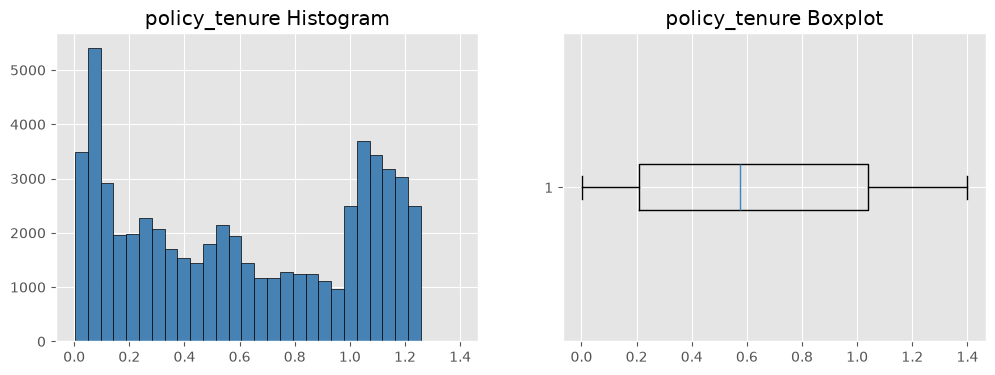

,feature,mean,median,std,min,25%,50%,75%,max,skewness,iqr_outlier_count
0,policy_tenure,0.6112,0.5738,0.4142,0.0027,0.2102,0.5738,1.0391,1.3966,0.0536,0


Interpretation for policy_tenure: distribution is roughly symmetric; median=0.5738, mean=0.6112, approximate IQR-based outliers=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\1024785670.py:29: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(train_df[column].dropna(), vert=False)


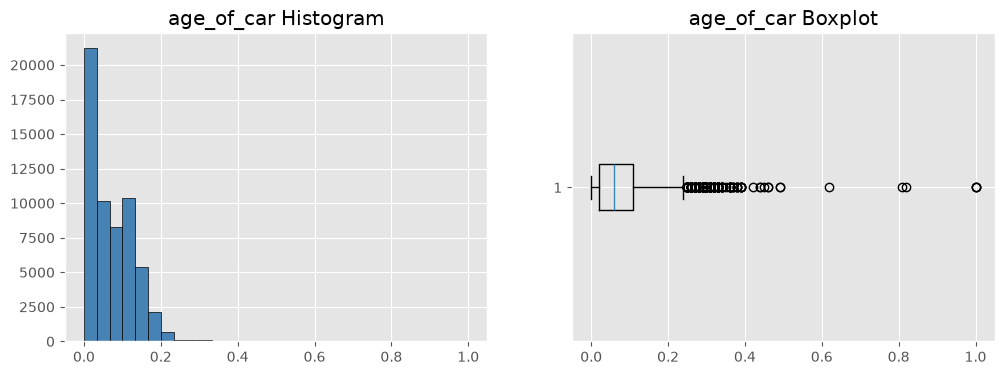

,feature,mean,median,std,min,25%,50%,75%,max,skewness,iqr_outlier_count
0,age_of_car,0.0694,0.06,0.0567,0.0,0.02,0.06,0.11,1.0,1.0941,269


Interpretation for age_of_car: distribution is strong right skew; median=0.0600, mean=0.0694, approximate IQR-based outliers=269.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\1024785670.py:29: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(train_df[column].dropna(), vert=False)


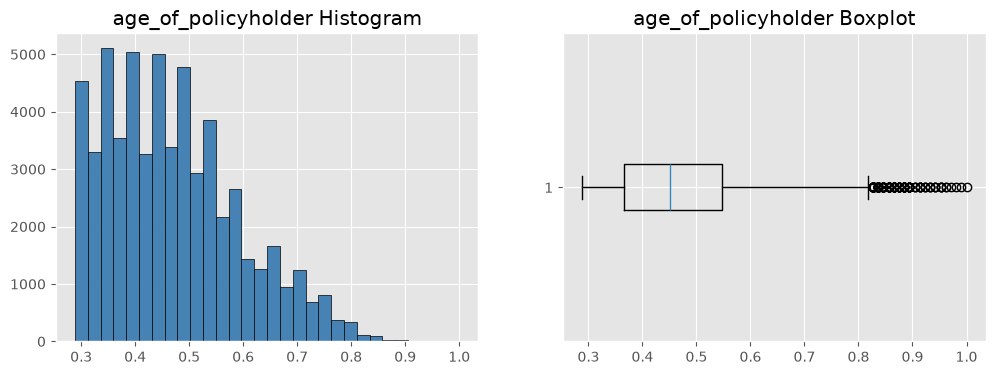

,feature,mean,median,std,min,25%,50%,75%,max,skewness,iqr_outlier_count
0,age_of_policyholder,0.4694,0.4519,0.1229,0.2885,0.3654,0.4519,0.5481,1.0,0.64,221


Interpretation for age_of_policyholder: distribution is moderate right skew; median=0.4519, mean=0.4694, approximate IQR-based outliers=221.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\1024785670.py:29: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(train_df[column].dropna(), vert=False)


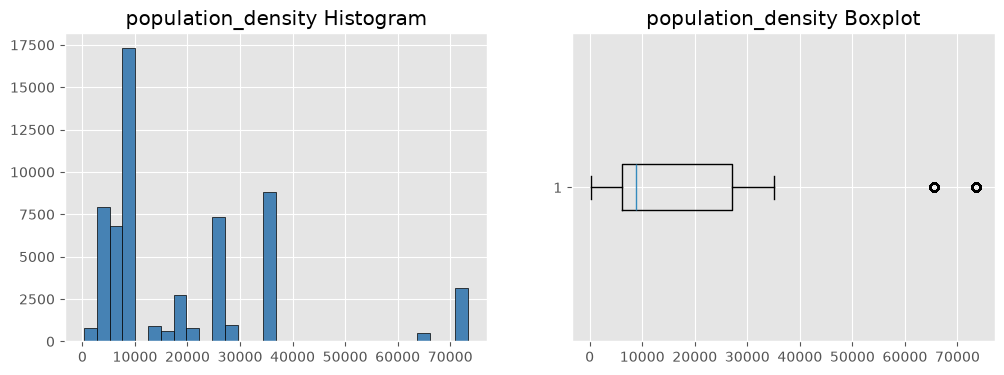

,feature,mean,median,std,min,25%,50%,75%,max,skewness,iqr_outlier_count
0,population_density,18826.8587,8794.0,17660.1748,290.0,6112.0,8794.0,27003.0,73430.0,1.6742,3647


Interpretation for population_density: distribution is strong right skew; median=8794.0000, mean=18826.8587, approximate IQR-based outliers=3647.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\1024785670.py:29: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(train_df[column].dropna(), vert=False)


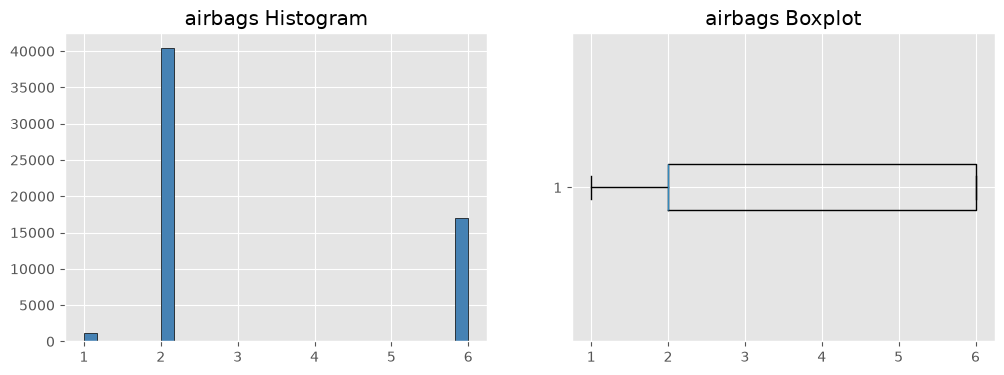

,feature,mean,median,std,min,25%,50%,75%,max,skewness,iqr_outlier_count
0,airbags,3.1371,2.0,1.8326,1.0,2.0,2.0,6.0,6.0,0.9059,0


Interpretation for airbags: distribution is moderate right skew; median=2.0000, mean=3.1371, approximate IQR-based outliers=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\1024785670.py:29: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(train_df[column].dropna(), vert=False)


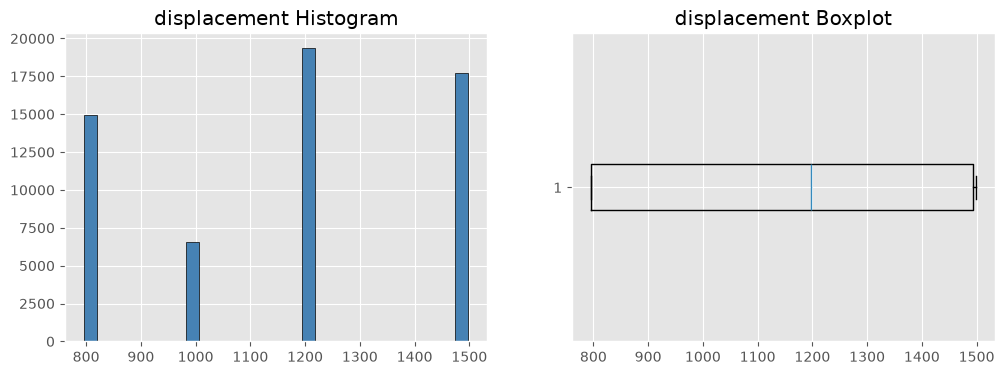

,feature,mean,median,std,min,25%,50%,75%,max,skewness,iqr_outlier_count
0,displacement,1162.3559,1197.0,266.3048,796.0,796.0,1197.0,1493.0,1498.0,-0.1053,0


Interpretation for displacement: distribution is roughly symmetric; median=1197.0000, mean=1162.3559, approximate IQR-based outliers=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\1024785670.py:29: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(train_df[column].dropna(), vert=False)


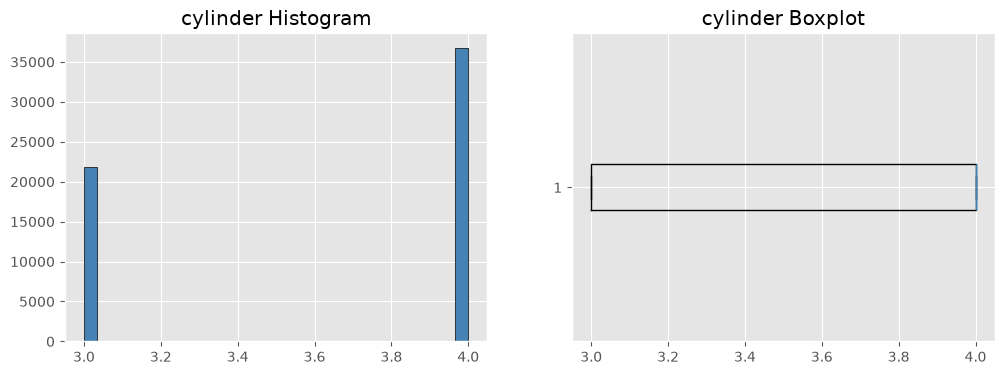

,feature,mean,median,std,min,25%,50%,75%,max,skewness,iqr_outlier_count
0,cylinder,3.627,4.0,0.4836,3.0,3.0,4.0,4.0,4.0,-0.5251,0


Interpretation for cylinder: distribution is moderate left skew; median=4.0000, mean=3.6270, approximate IQR-based outliers=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\1024785670.py:29: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(train_df[column].dropna(), vert=False)


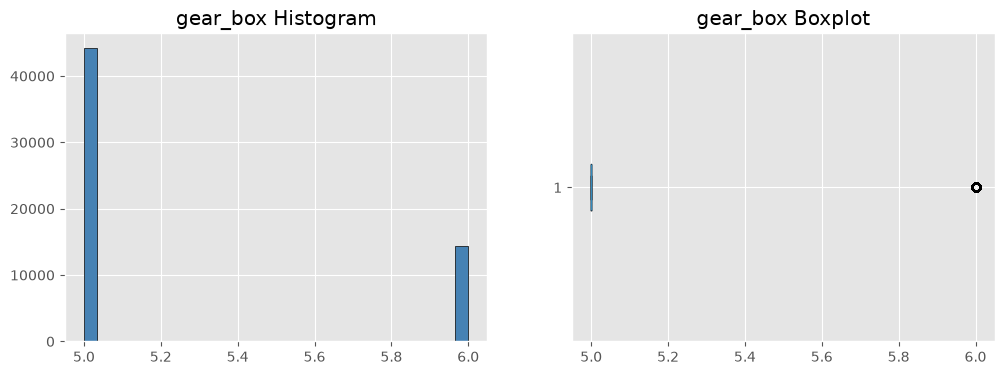

,feature,mean,median,std,min,25%,50%,75%,max,skewness,iqr_outlier_count
0,gear_box,5.2454,5.0,0.4304,5.0,5.0,5.0,5.0,6.0,1.1831,14381


Interpretation for gear_box: distribution is strong right skew; median=5.0000, mean=5.2454, approximate IQR-based outliers=14381.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\1024785670.py:29: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(train_df[column].dropna(), vert=False)


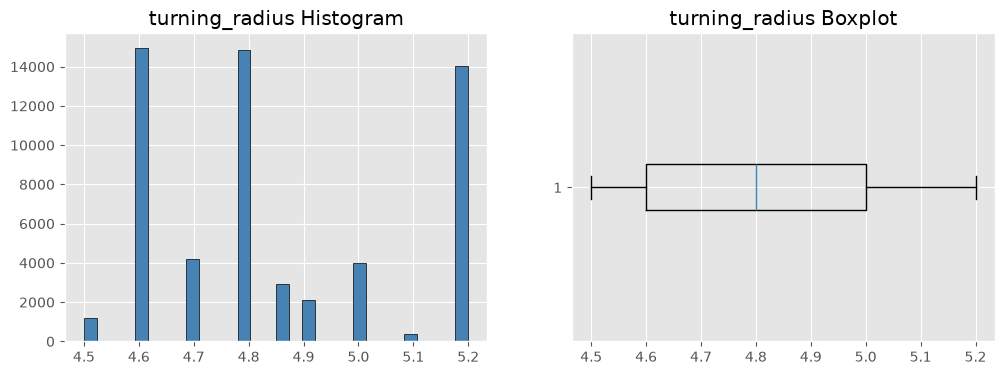

,feature,mean,median,std,min,25%,50%,75%,max,skewness,iqr_outlier_count
0,turning_radius,4.8529,4.8,0.2281,4.5,4.6,4.8,5.0,5.2,0.421,0


Interpretation for turning_radius: distribution is moderate right skew; median=4.8000, mean=4.8529, approximate IQR-based outliers=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\1024785670.py:29: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(train_df[column].dropna(), vert=False)


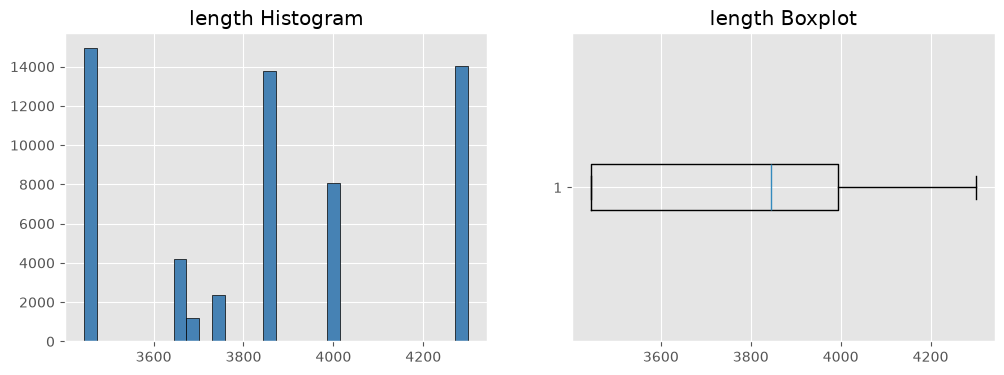

,feature,mean,median,std,min,25%,50%,75%,max,skewness,iqr_outlier_count
0,length,3850.4769,3845.0,311.4571,3445.0,3445.0,3845.0,3995.0,4300.0,0.1458,0


Interpretation for length: distribution is roughly symmetric; median=3845.0000, mean=3850.4769, approximate IQR-based outliers=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\1024785670.py:29: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(train_df[column].dropna(), vert=False)


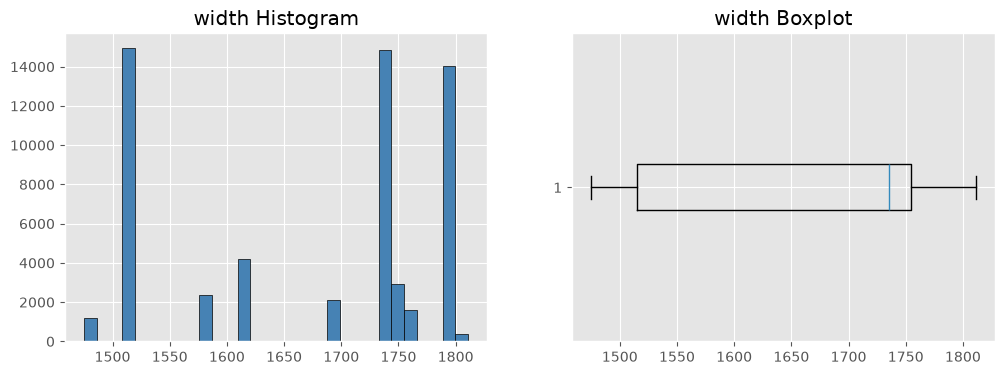

,feature,mean,median,std,min,25%,50%,75%,max,skewness,iqr_outlier_count
0,width,1672.2337,1735.0,112.0891,1475.0,1515.0,1735.0,1755.0,1811.0,-0.4884,0


Interpretation for width: distribution is moderate left skew; median=1735.0000, mean=1672.2337, approximate IQR-based outliers=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\1024785670.py:29: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(train_df[column].dropna(), vert=False)


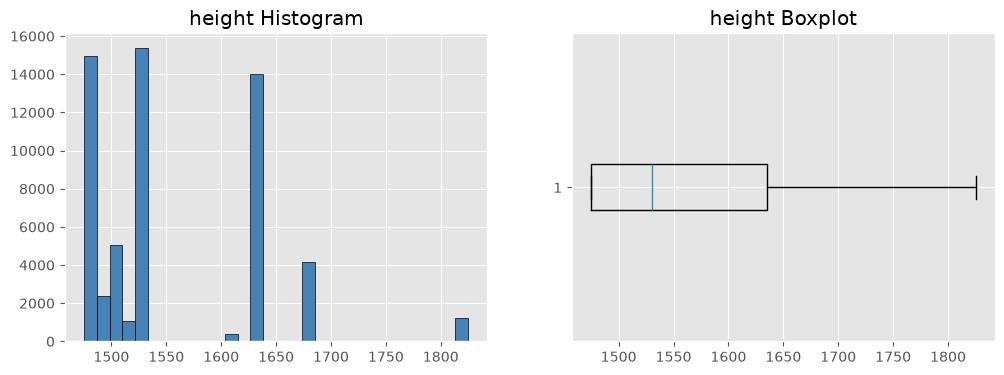

,feature,mean,median,std,min,25%,50%,75%,max,skewness,iqr_outlier_count
0,height,1553.3354,1530.0,79.6223,1475.0,1475.0,1530.0,1635.0,1825.0,1.0355,0


Interpretation for height: distribution is strong right skew; median=1530.0000, mean=1553.3354, approximate IQR-based outliers=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\1024785670.py:29: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(train_df[column].dropna(), vert=False)


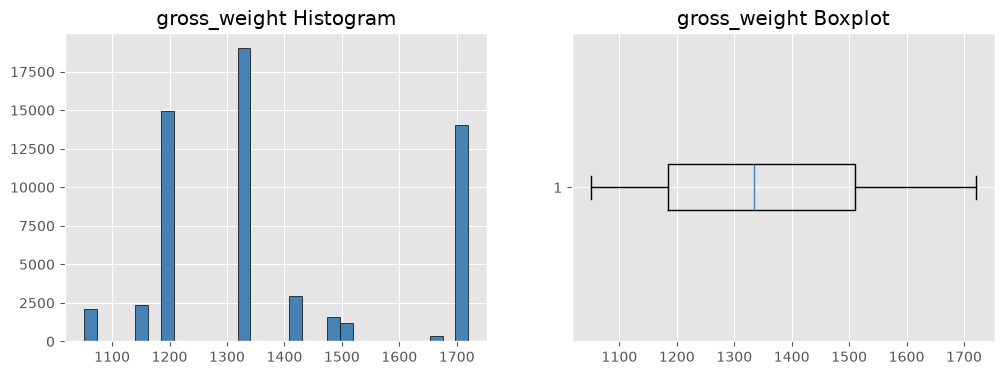

,feature,mean,median,std,min,25%,50%,75%,max,skewness,iqr_outlier_count
0,gross_weight,1385.2768,1335.0,212.4231,1051.0,1185.0,1335.0,1510.0,1720.0,0.5469,0


Interpretation for gross_weight: distribution is moderate right skew; median=1335.0000, mean=1385.2768, approximate IQR-based outliers=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\1024785670.py:29: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(train_df[column].dropna(), vert=False)


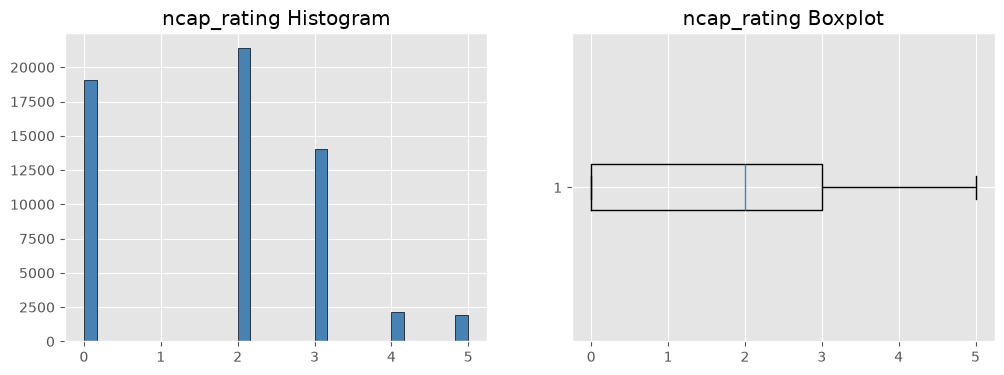

,feature,mean,median,std,min,25%,50%,75%,max,skewness,iqr_outlier_count
0,ncap_rating,1.76,2.0,1.3896,0.0,0.0,2.0,3.0,5.0,0.0851,0


Interpretation for ncap_rating: distribution is roughly symmetric; median=2.0000, mean=1.7600, approximate IQR-based outliers=0.


In [7]:
def iqr_outlier_count(series: pd.Series) -> int:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())


def interpret_skew(skew_value: float) -> str:
    if skew_value > 1:
        return 'strong right skew'
    if skew_value > 0.3:
        return 'moderate right skew'
    if skew_value < -1:
        return 'strong left skew'
    if skew_value < -0.3:
        return 'moderate left skew'
    return 'roughly symmetric'


for column in da.NUMERICAL_FEATURES:
    stats_row = numeric_stats.loc[column]
    outlier_count = iqr_outlier_count(train_df[column])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(train_df[column], bins=30, color='steelblue', edgecolor='black')
    axes[0].set_title(f'{column} Histogram')
    axes[1].boxplot(train_df[column].dropna(), vert=False)
    axes[1].set_title(f'{column} Boxplot')
    plt.show()

    display(pd.DataFrame([{
        'feature': column,
        'mean': stats_row['mean'],
        'median': stats_row['median'],
        'std': stats_row['std'],
        'min': stats_row['min'],
        '25%': stats_row['25%'],
        '50%': stats_row['50%'],
        '75%': stats_row['75%'],
        'max': stats_row['max'],
        'skewness': stats_row['skewness'],
        'iqr_outlier_count': outlier_count,
    }]).round(4))

    print(
        f"Interpretation for {column}: distribution is {interpret_skew(stats_row['skewness'])}; "
        f"median={stats_row['median']:.4f}, mean={stats_row['mean']:.4f}, "
        f"approximate IQR-based outliers={outlier_count}."
    )

### Numerical Summary Interpretation

- `policy_tenure` shows the clearest univariate relationship with the target later in this notebook and has the strongest linear correlation with `is_claim` among the audited numeric fields.
- Several numeric variables appear scaled or normalized already, especially `age_of_car` and `age_of_policyholder`, both of which stay within **0 to 1**.
- `population_density` is visibly right-skewed and spans a wide range, so it is likely to need transformation or scaling in a later sprint.
- Physical vehicle dimensions and mechanical counts are internally consistent, but some of them have limited cardinality and may behave more like discrete structured inputs than smooth continuous variables.


## Phase 5 - Categorical Feature Analysis

C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


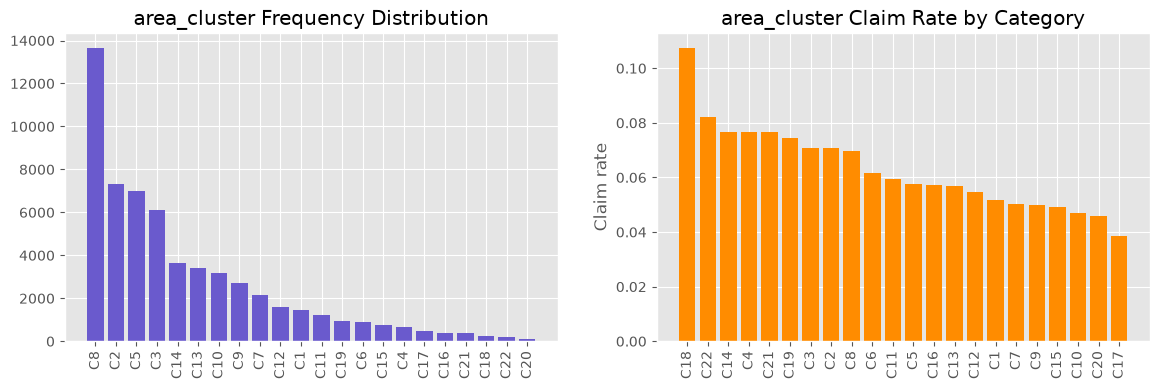

,category,count,percentage
0,C8,13654,23.3035
1,C2,7342,12.5307
2,C5,6979,11.9112
3,C3,6101,10.4127
4,C14,3660,6.2466
5,C13,3423,5.8421
6,C10,3155,5.3847
7,C9,2734,4.6662
8,C7,2167,3.6985
9,C12,1589,2.7120


,area_cluster,claim_rate,row_count
0,C18,0.107438,242
1,C22,0.082126,207
2,C14,0.076776,3660
3,C4,0.076692,665
4,C21,0.076517,379
5,C19,0.074580,952
6,C3,0.070972,6101
7,C2,0.070825,7342
8,C8,0.069870,13654
9,C6,0.061798,890


Interpretation for area_cluster: cardinality=22, dominant category share=23.30%, rare categories (<1% of rows)=6.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


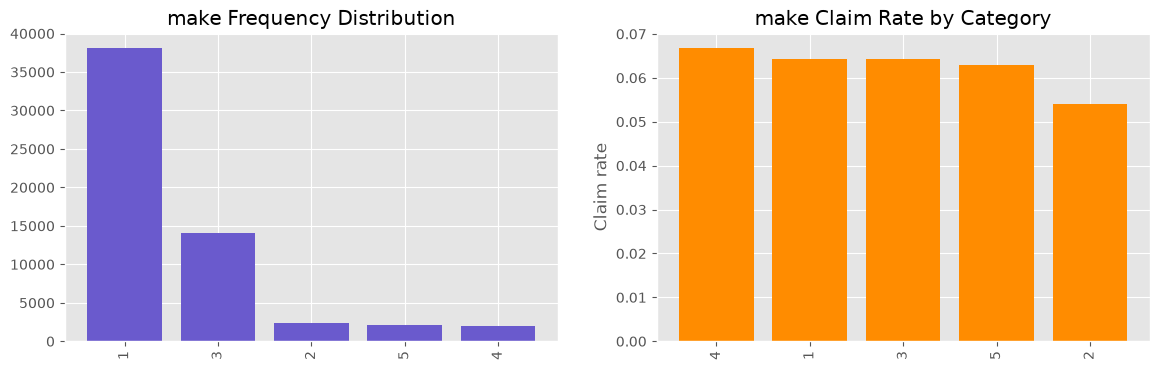

,category,count,percentage
0,1,38126,65.0703
1,3,14018,23.9248
2,2,2373,4.0500
3,5,2114,3.6080
4,4,1961,3.3469


,make,claim_rate,row_count
0,4,0.066803,1961
1,1,0.064392,38126
2,3,0.064275,14018
3,5,0.062914,2114
4,2,0.053940,2373


Interpretation for make: cardinality=5, dominant category share=65.07%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


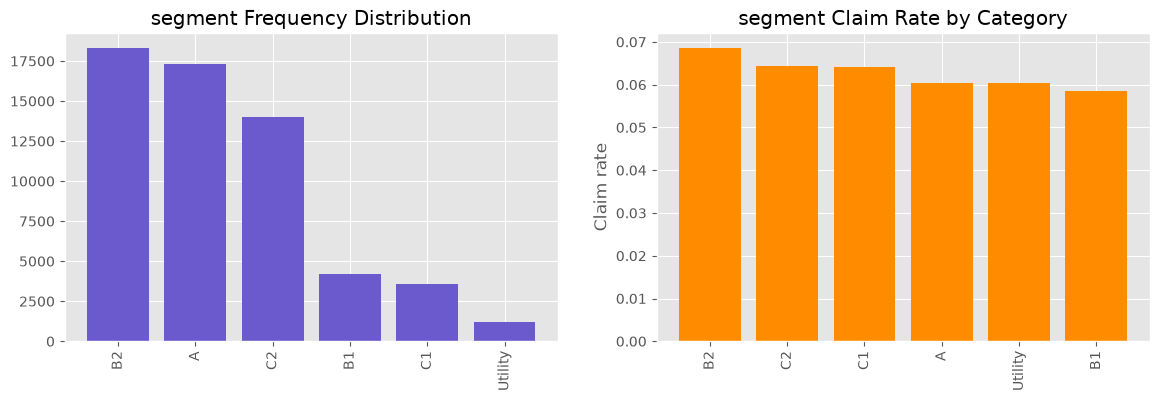

,category,count,percentage
0,B2,18314,31.2568
1,A,17321,29.5621
2,C2,14018,23.9248
3,B1,4173,7.1221
4,C1,3557,6.0708
5,Utility,1209,2.0634


,segment,claim_rate,row_count
0,B2,0.068581,18314
1,C2,0.064275,14018
2,C1,0.064099,3557
3,A,0.060389,17321
4,Utility,0.060380,1209
5,B1,0.058471,4173


Interpretation for segment: cardinality=6, dominant category share=31.26%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


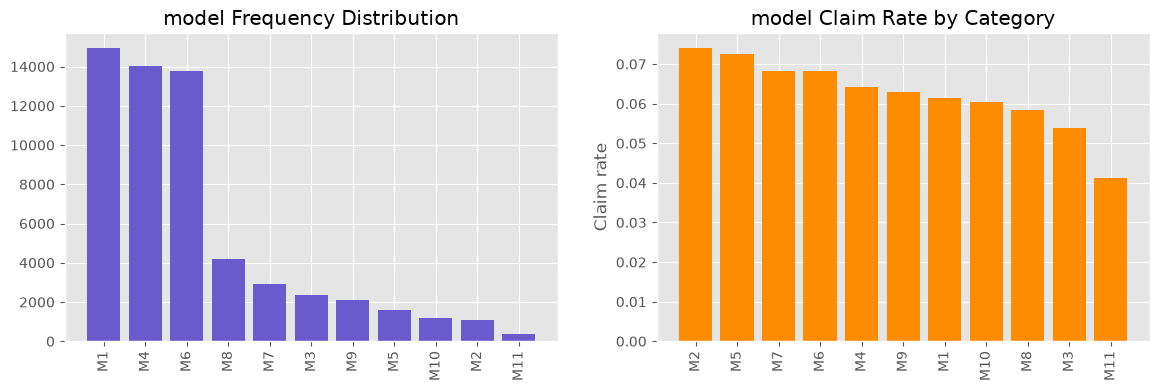

,category,count,percentage
0,M1,14948,25.5120
1,M4,14018,23.9248
2,M6,13776,23.5117
3,M8,4173,7.1221
4,M7,2940,5.0177
5,M3,2373,4.0500
6,M9,2114,3.6080
7,M5,1598,2.7273
8,M10,1209,2.0634
9,M2,1080,1.8433


,model,claim_rate,row_count
0,M2,0.074074,1080
1,M5,0.072591,1598
2,M7,0.068367,2940
3,M6,0.068162,13776
4,M4,0.064275,14018
5,M9,0.062914,2114
6,M1,0.061413,14948
7,M10,0.060380,1209
8,M8,0.058471,4173
9,M3,0.053940,2373


Interpretation for model: cardinality=11, dominant category share=25.51%, rare categories (<1% of rows)=1.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


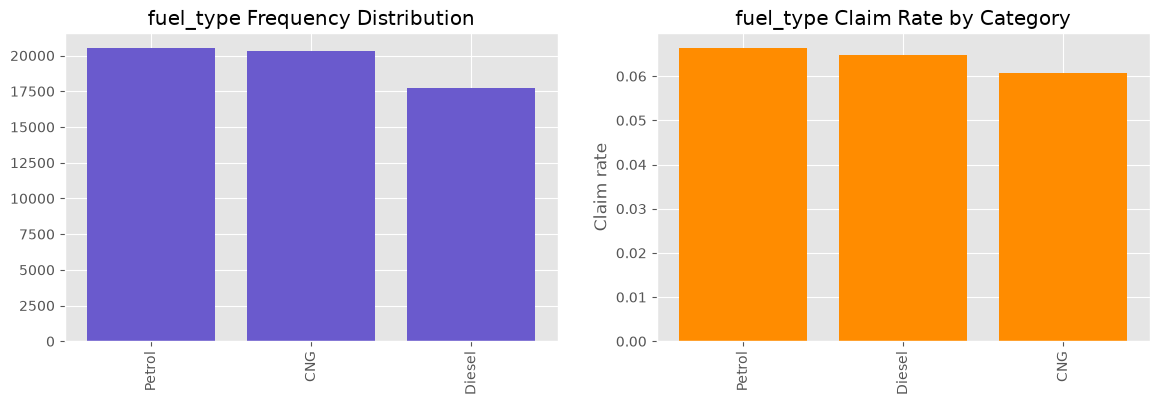

,category,count,percentage
0,Petrol,20532,35.0423
1,CNG,20330,34.6976
2,Diesel,17730,30.2601


,fuel_type,claim_rate,row_count
0,Petrol,0.066384,20532
1,Diesel,0.064862,17730
2,CNG,0.060748,20330


Interpretation for fuel_type: cardinality=3, dominant category share=35.04%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


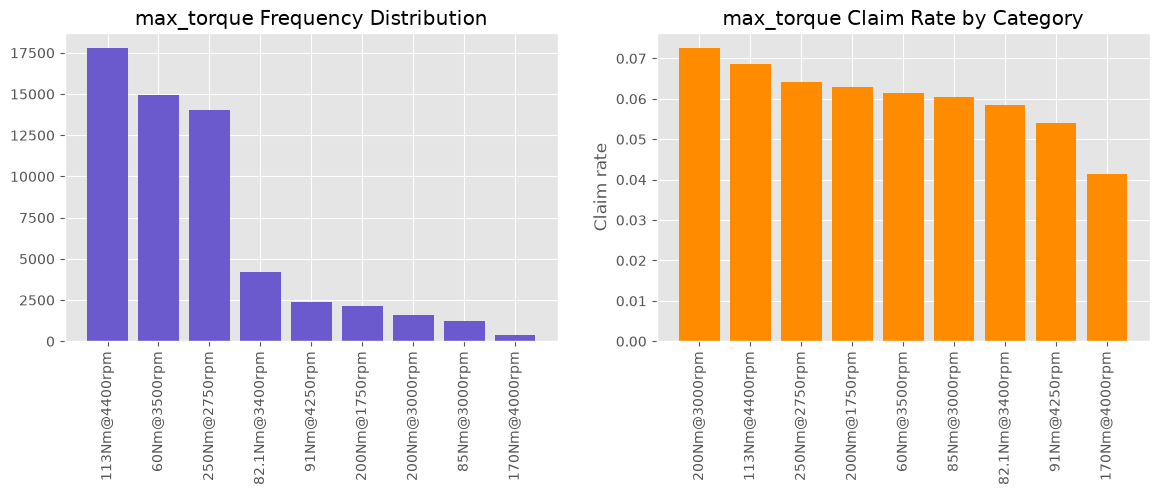

,category,count,percentage
0,113Nm@4400rpm,17796,30.3727
1,60Nm@3500rpm,14948,25.5120
2,250Nm@2750rpm,14018,23.9248
3,82.1Nm@3400rpm,4173,7.1221
4,91Nm@4250rpm,2373,4.0500
5,200Nm@1750rpm,2114,3.6080
6,200Nm@3000rpm,1598,2.7273
7,85Nm@3000rpm,1209,2.0634
8,170Nm@4000rpm,363,0.6195


,max_torque,claim_rate,row_count
0,200Nm@3000rpm,0.072591,1598
1,113Nm@4400rpm,0.068555,17796
2,250Nm@2750rpm,0.064275,14018
3,200Nm@1750rpm,0.062914,2114
4,60Nm@3500rpm,0.061413,14948
5,85Nm@3000rpm,0.060380,1209
6,82.1Nm@3400rpm,0.058471,4173
7,91Nm@4250rpm,0.053940,2373
8,170Nm@4000rpm,0.041322,363


Interpretation for max_torque: cardinality=9, dominant category share=30.37%, rare categories (<1% of rows)=1.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


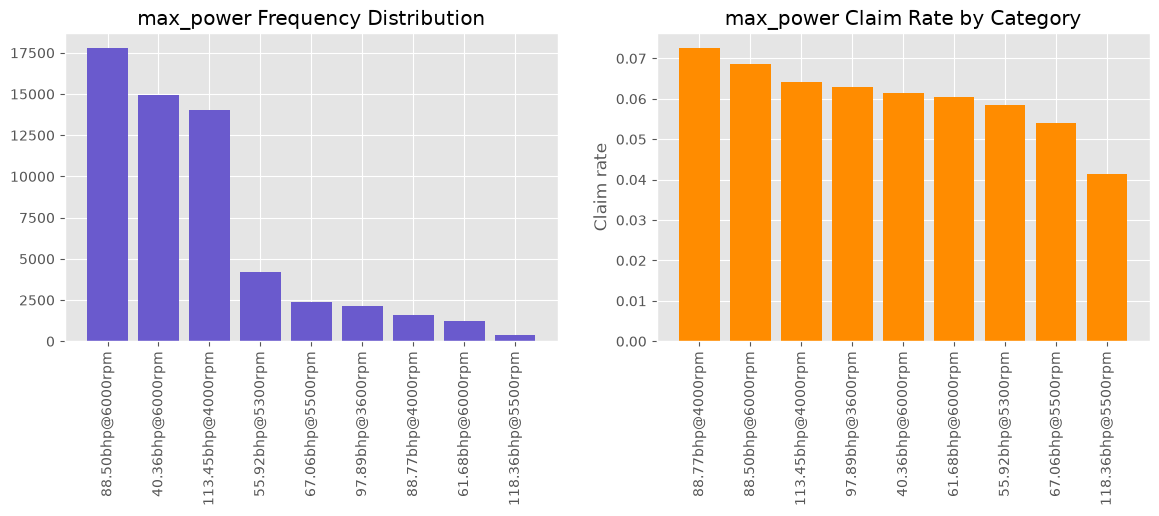

,category,count,percentage
0,88.50bhp@6000rpm,17796,30.3727
1,40.36bhp@6000rpm,14948,25.5120
2,113.45bhp@4000rpm,14018,23.9248
3,55.92bhp@5300rpm,4173,7.1221
4,67.06bhp@5500rpm,2373,4.0500
5,97.89bhp@3600rpm,2114,3.6080
6,88.77bhp@4000rpm,1598,2.7273
7,61.68bhp@6000rpm,1209,2.0634
8,118.36bhp@5500rpm,363,0.6195


,max_power,claim_rate,row_count
0,88.77bhp@4000rpm,0.072591,1598
1,88.50bhp@6000rpm,0.068555,17796
2,113.45bhp@4000rpm,0.064275,14018
3,97.89bhp@3600rpm,0.062914,2114
4,40.36bhp@6000rpm,0.061413,14948
5,61.68bhp@6000rpm,0.060380,1209
6,55.92bhp@5300rpm,0.058471,4173
7,67.06bhp@5500rpm,0.053940,2373
8,118.36bhp@5500rpm,0.041322,363


Interpretation for max_power: cardinality=9, dominant category share=30.37%, rare categories (<1% of rows)=1.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


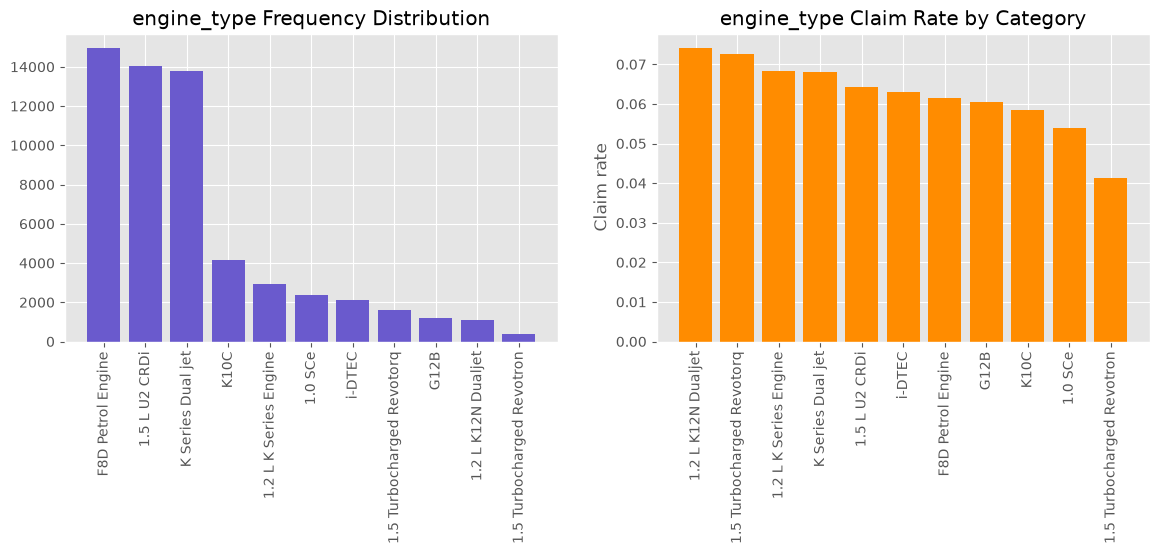

,category,count,percentage
0,F8D Petrol Engine,14948,25.5120
1,1.5 L U2 CRDi,14018,23.9248
2,K Series Dual jet,13776,23.5117
3,K10C,4173,7.1221
4,1.2 L K Series Engine,2940,5.0177
5,1.0 SCe,2373,4.0500
6,i-DTEC,2114,3.6080
7,1.5 Turbocharged Revotorq,1598,2.7273
8,G12B,1209,2.0634
9,1.2 L K12N Dualjet,1080,1.8433


,engine_type,claim_rate,row_count
0,1.2 L K12N Dualjet,0.074074,1080
1,1.5 Turbocharged Revotorq,0.072591,1598
2,1.2 L K Series Engine,0.068367,2940
3,K Series Dual jet,0.068162,13776
4,1.5 L U2 CRDi,0.064275,14018
5,i-DTEC,0.062914,2114
6,F8D Petrol Engine,0.061413,14948
7,G12B,0.060380,1209
8,K10C,0.058471,4173
9,1.0 SCe,0.053940,2373


Interpretation for engine_type: cardinality=11, dominant category share=25.51%, rare categories (<1% of rows)=1.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


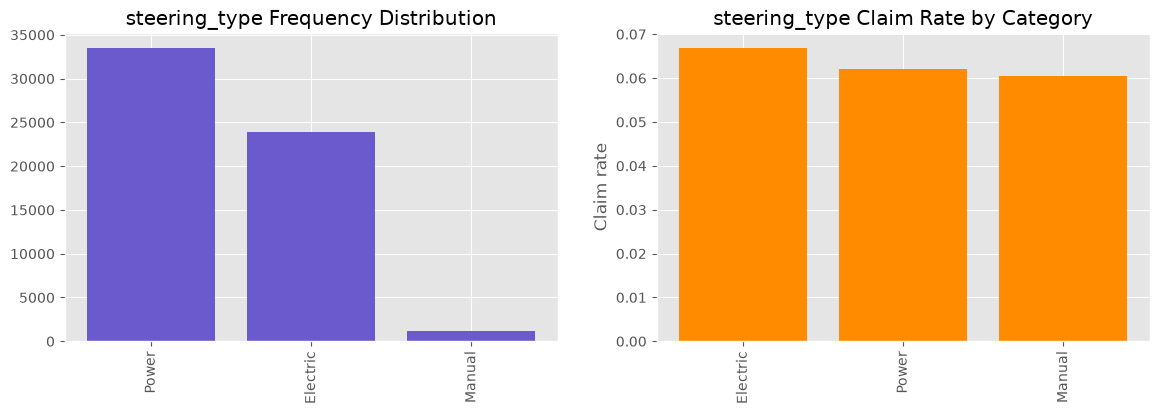

,category,count,percentage
0,Power,33502,57.1785
1,Electric,23881,40.7581
2,Manual,1209,2.0634


,steering_type,claim_rate,row_count
0,Electric,0.066873,23881
1,Power,0.062026,33502
2,Manual,0.060380,1209


Interpretation for steering_type: cardinality=3, dominant category share=57.18%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


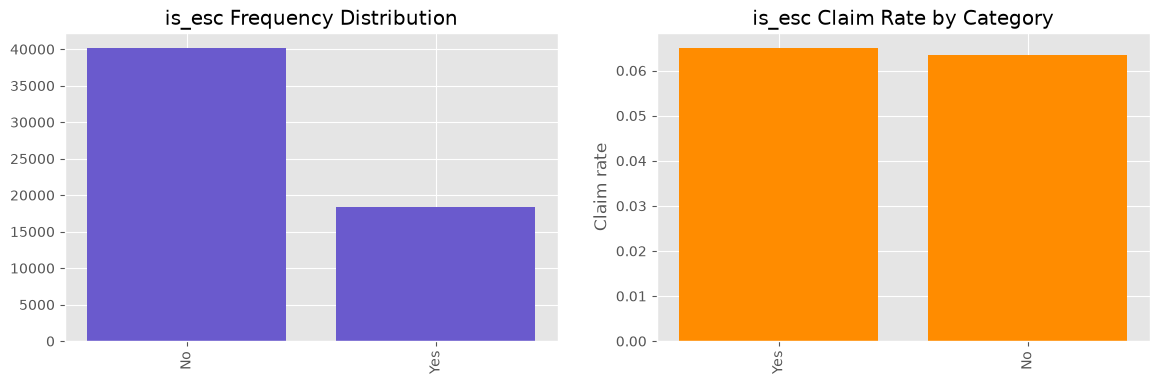

,category,count,percentage
0,No,40191,68.5947
1,Yes,18401,31.4053


,is_esc,claim_rate,row_count
0,Yes,0.065051,18401
1,No,0.063472,40191


Interpretation for is_esc: cardinality=2, dominant category share=68.59%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


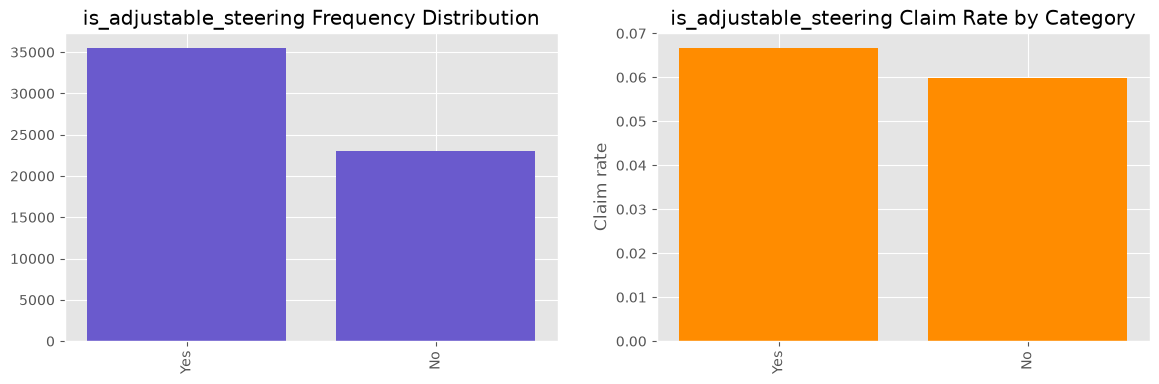

,category,count,percentage
0,Yes,35526,60.6329
1,No,23066,39.3671


,is_adjustable_steering,claim_rate,row_count
0,Yes,0.066712,35526
1,No,0.059742,23066


Interpretation for is_adjustable_steering: cardinality=2, dominant category share=60.63%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


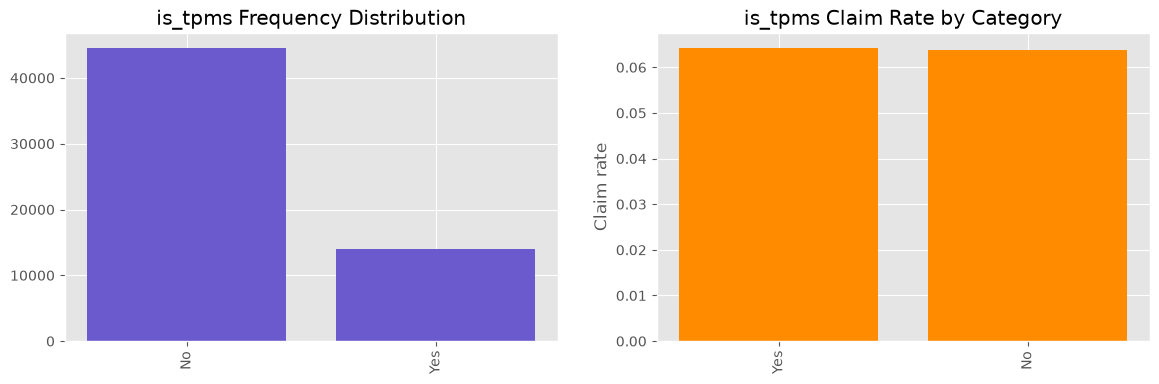

,category,count,percentage
0,No,44574,76.0752
1,Yes,14018,23.9248


,is_tpms,claim_rate,row_count
0,Yes,0.064275,14018
1,No,0.063871,44574


Interpretation for is_tpms: cardinality=2, dominant category share=76.08%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


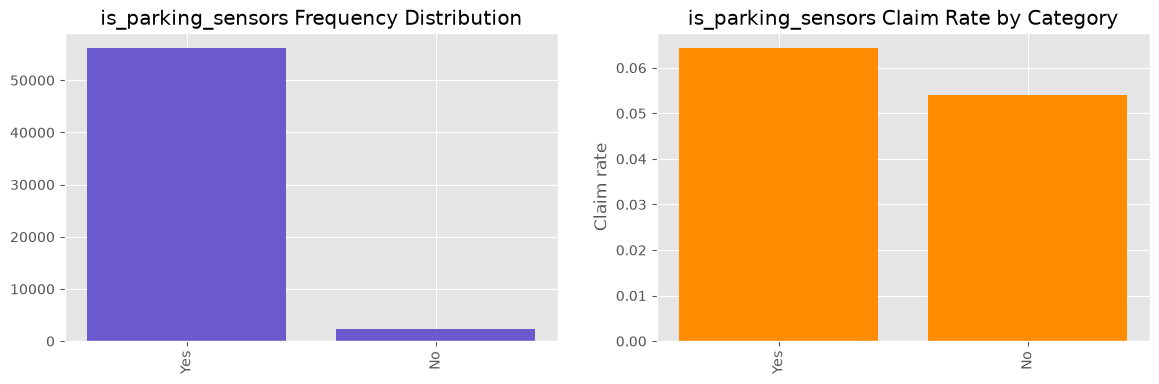

,category,count,percentage
0,Yes,56219,95.95
1,No,2373,4.05


,is_parking_sensors,claim_rate,row_count
0,Yes,0.064391,56219
1,No,0.053940,2373


Interpretation for is_parking_sensors: cardinality=2, dominant category share=95.95%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


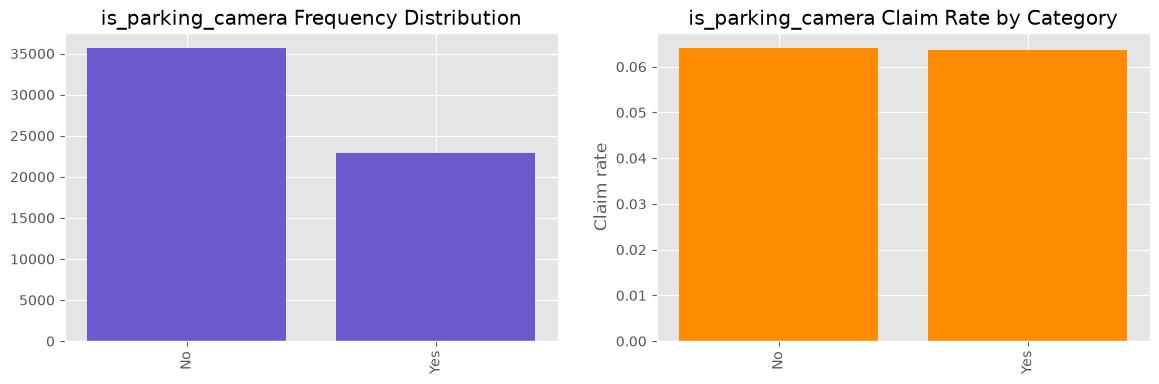

,category,count,percentage
0,No,35704,60.9366
1,Yes,22888,39.0634


,is_parking_camera,claim_rate,row_count
0,No,0.064138,35704
1,Yes,0.063702,22888


Interpretation for is_parking_camera: cardinality=2, dominant category share=60.94%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


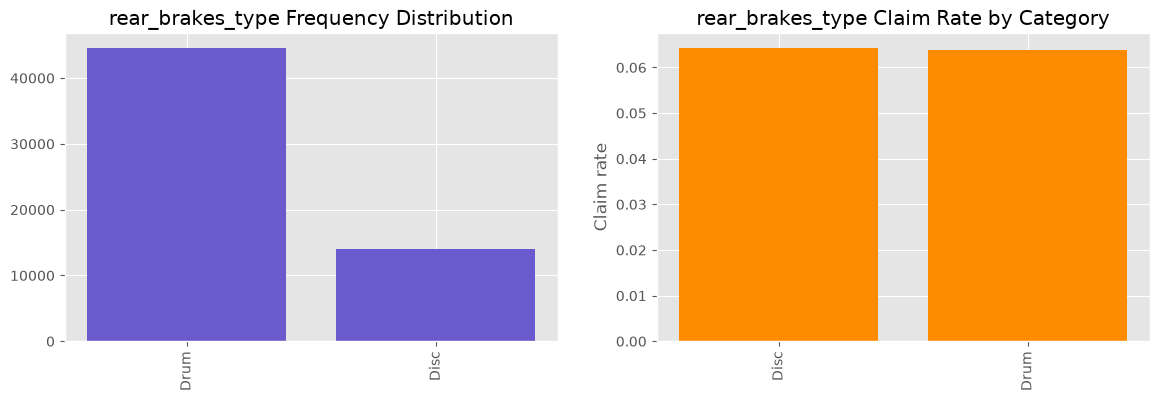

,category,count,percentage
0,Drum,44574,76.0752
1,Disc,14018,23.9248


,rear_brakes_type,claim_rate,row_count
0,Disc,0.064275,14018
1,Drum,0.063871,44574


Interpretation for rear_brakes_type: cardinality=2, dominant category share=76.08%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


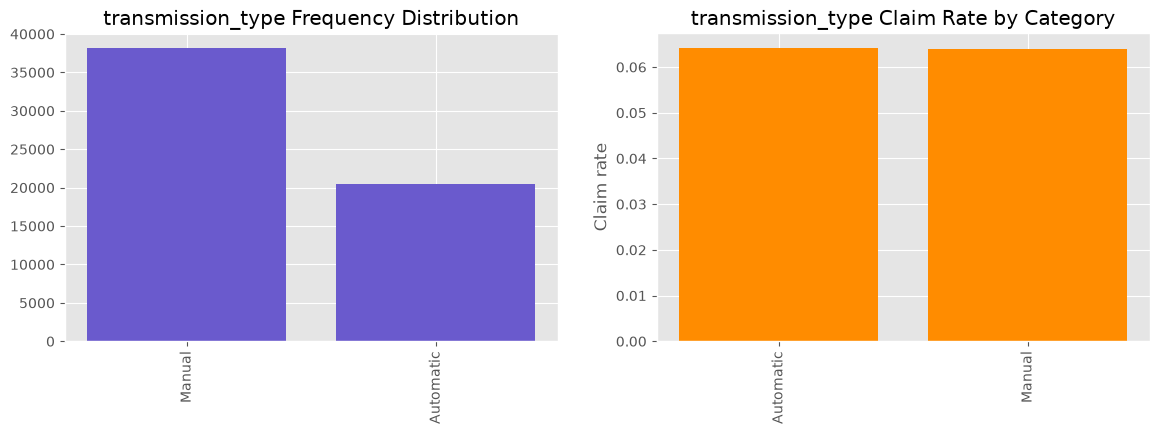

,category,count,percentage
0,Manual,38181,65.1642
1,Automatic,20411,34.8358


,transmission_type,claim_rate,row_count
0,Automatic,0.064181,20411
1,Manual,0.063854,38181


Interpretation for transmission_type: cardinality=2, dominant category share=65.16%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


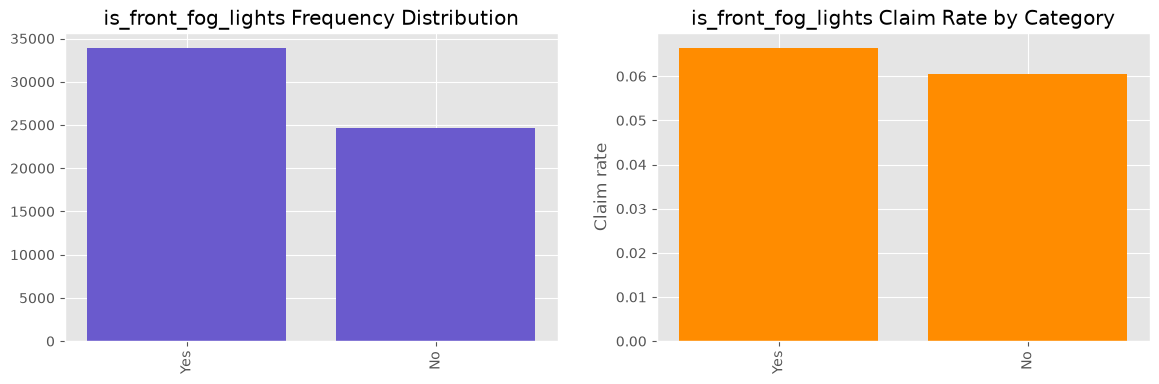

,category,count,percentage
0,Yes,33928,57.9055
1,No,24664,42.0945


,is_front_fog_lights,claim_rate,row_count
0,Yes,0.066435,33928
1,No,0.060574,24664


Interpretation for is_front_fog_lights: cardinality=2, dominant category share=57.91%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


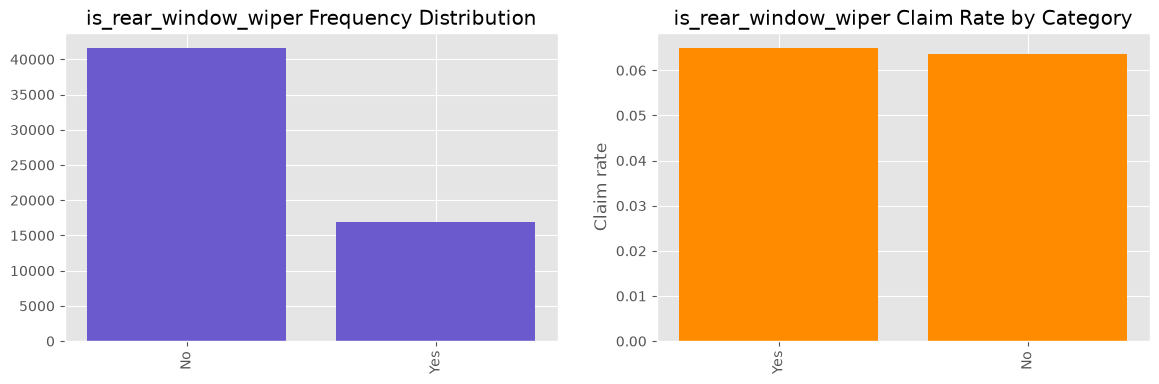

,category,count,percentage
0,No,41634,71.0575
1,Yes,16958,28.9425


,is_rear_window_wiper,claim_rate,row_count
0,Yes,0.064984,16958
1,No,0.063554,41634


Interpretation for is_rear_window_wiper: cardinality=2, dominant category share=71.06%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


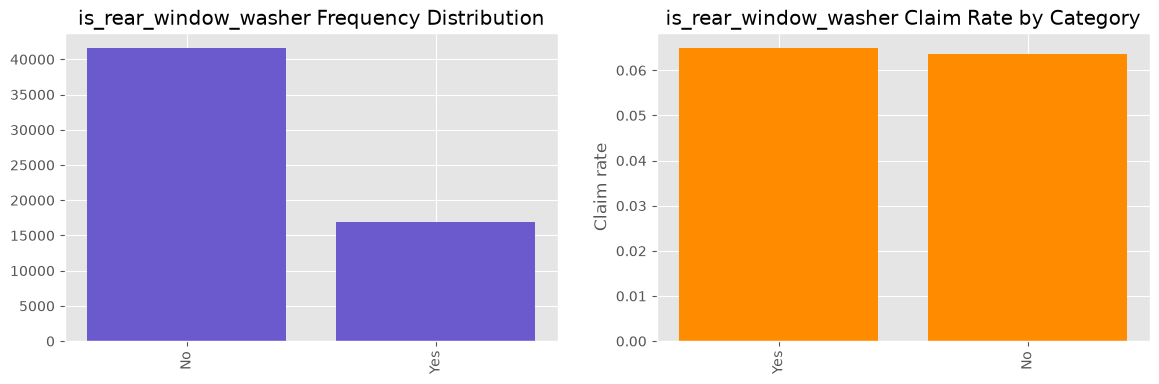

,category,count,percentage
0,No,41634,71.0575
1,Yes,16958,28.9425


,is_rear_window_washer,claim_rate,row_count
0,Yes,0.064984,16958
1,No,0.063554,41634


Interpretation for is_rear_window_washer: cardinality=2, dominant category share=71.06%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


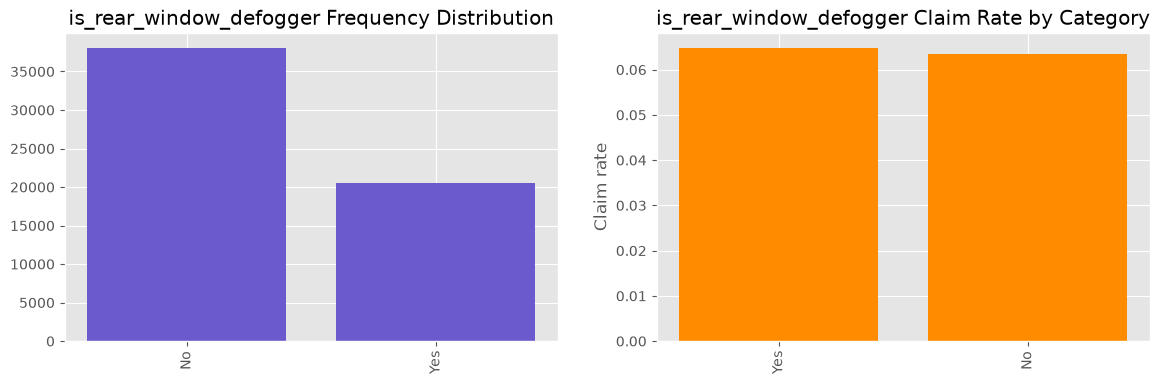

,category,count,percentage
0,No,38077,64.9867
1,Yes,20515,35.0133


,is_rear_window_defogger,claim_rate,row_count
0,Yes,0.064831,20515
1,No,0.063503,38077


Interpretation for is_rear_window_defogger: cardinality=2, dominant category share=64.99%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


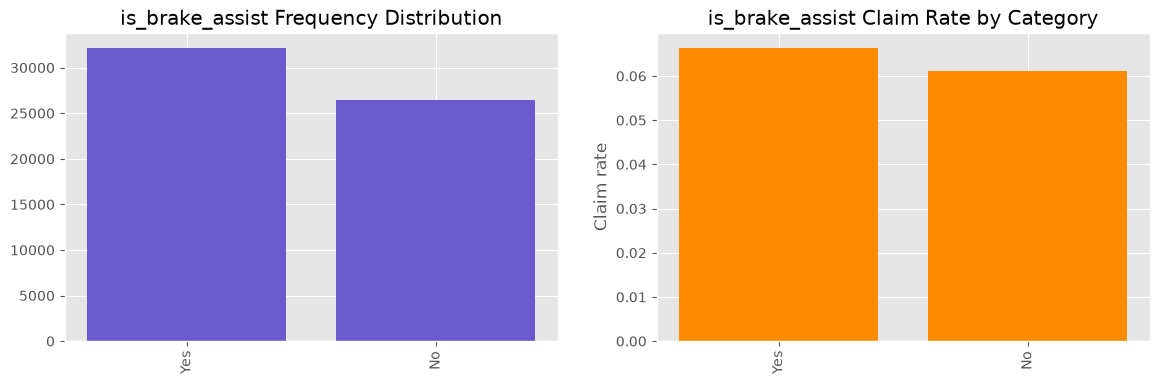

,category,count,percentage
0,Yes,32177,54.9171
1,No,26415,45.0829


,is_brake_assist,claim_rate,row_count
0,Yes,0.066383,32177
1,No,0.061026,26415


Interpretation for is_brake_assist: cardinality=2, dominant category share=54.92%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


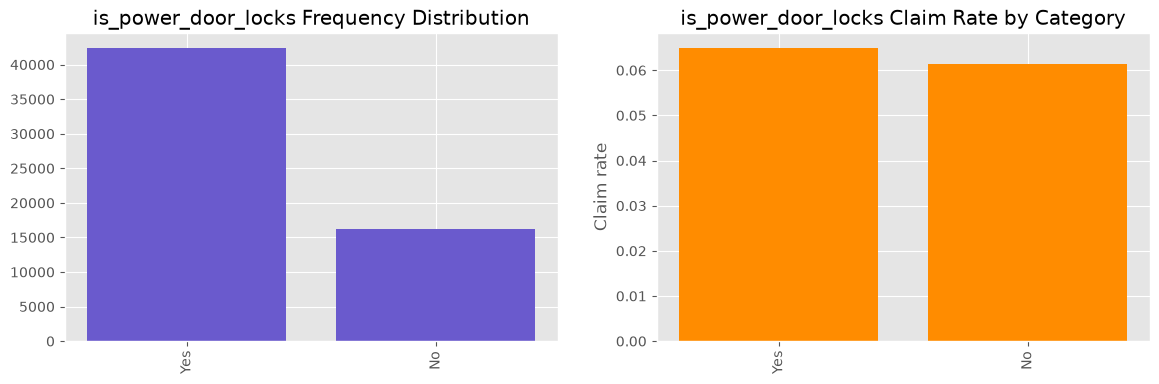

,category,count,percentage
0,Yes,42435,72.4246
1,No,16157,27.5754


,is_power_door_locks,claim_rate,row_count
0,Yes,0.064970,42435
1,No,0.061336,16157


Interpretation for is_power_door_locks: cardinality=2, dominant category share=72.42%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


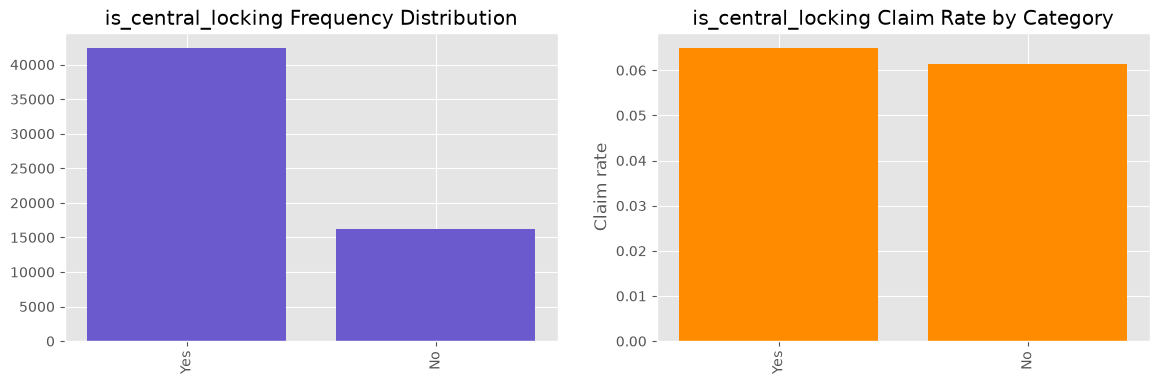

,category,count,percentage
0,Yes,42435,72.4246
1,No,16157,27.5754


,is_central_locking,claim_rate,row_count
0,Yes,0.064970,42435
1,No,0.061336,16157


Interpretation for is_central_locking: cardinality=2, dominant category share=72.42%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


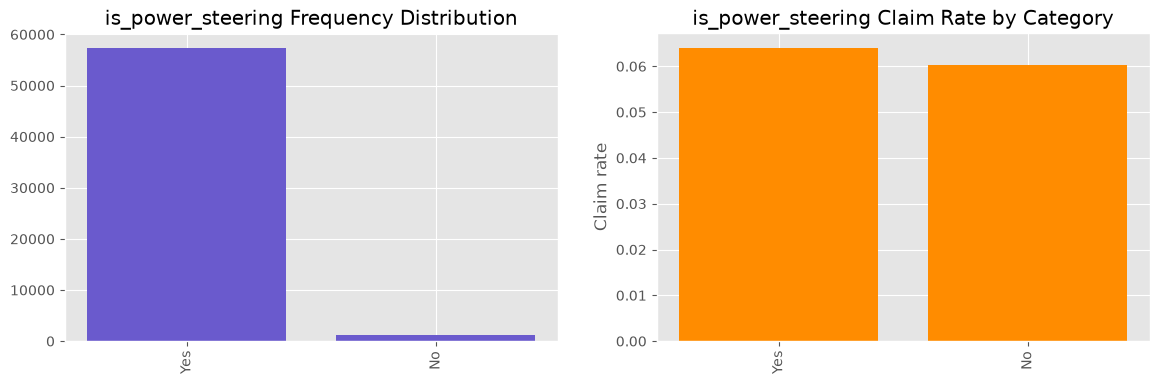

,category,count,percentage
0,Yes,57383,97.9366
1,No,1209,2.0634


,is_power_steering,claim_rate,row_count
0,Yes,0.064043,57383
1,No,0.060380,1209


Interpretation for is_power_steering: cardinality=2, dominant category share=97.94%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


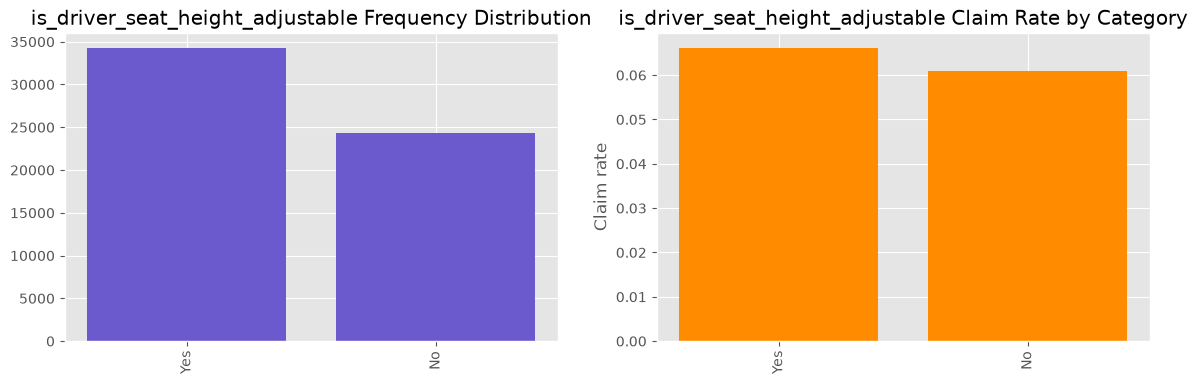

,category,count,percentage
0,Yes,34291,58.5251
1,No,24301,41.4749


,is_driver_seat_height_adjustable,claim_rate,row_count
0,Yes,0.066169,34291
1,No,0.060862,24301


Interpretation for is_driver_seat_height_adjustable: cardinality=2, dominant category share=58.53%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


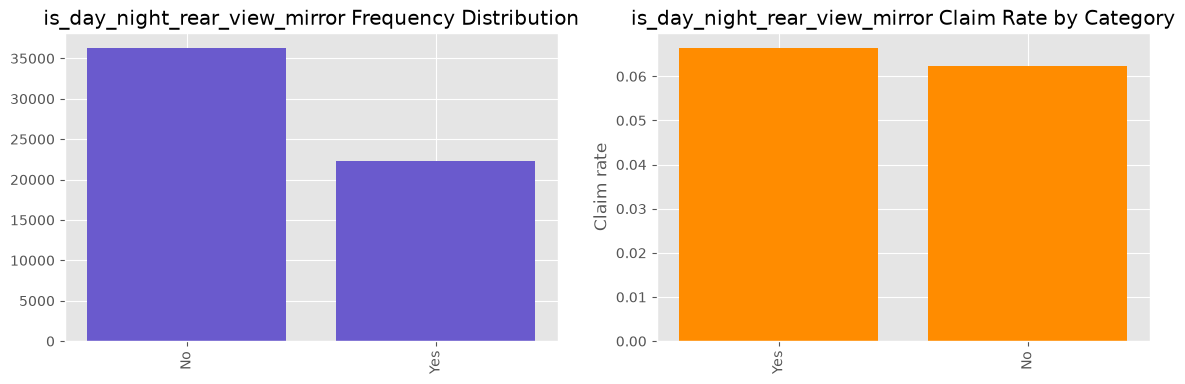

,category,count,percentage
0,No,36309,61.9692
1,Yes,22283,38.0308


,is_day_night_rear_view_mirror,claim_rate,row_count
0,Yes,0.066463,22283
1,No,0.062436,36309


Interpretation for is_day_night_rear_view_mirror: cardinality=2, dominant category share=61.97%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


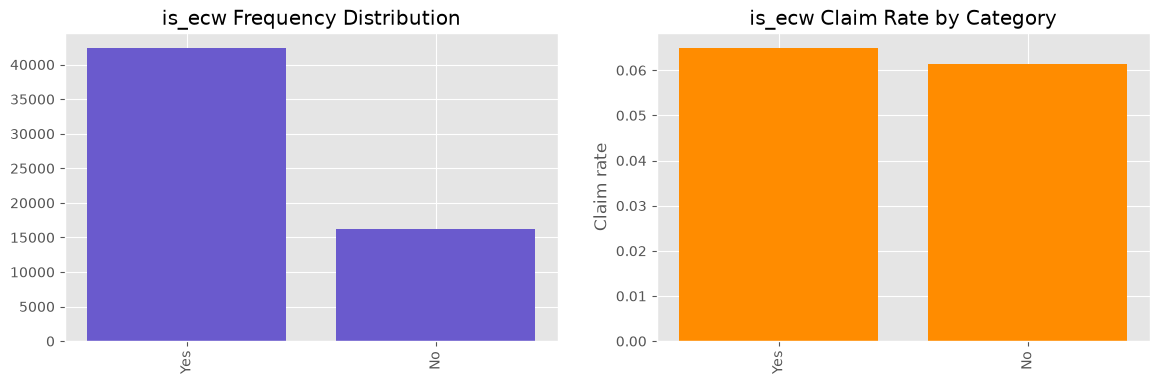

,category,count,percentage
0,Yes,42435,72.4246
1,No,16157,27.5754


,is_ecw,claim_rate,row_count
0,Yes,0.064970,42435
1,No,0.061336,16157


Interpretation for is_ecw: cardinality=2, dominant category share=72.42%, rare categories (<1% of rows)=0.


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(frequency['category'], rotation=90)
C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3486450539.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(claim_rates[column], rotation=90)


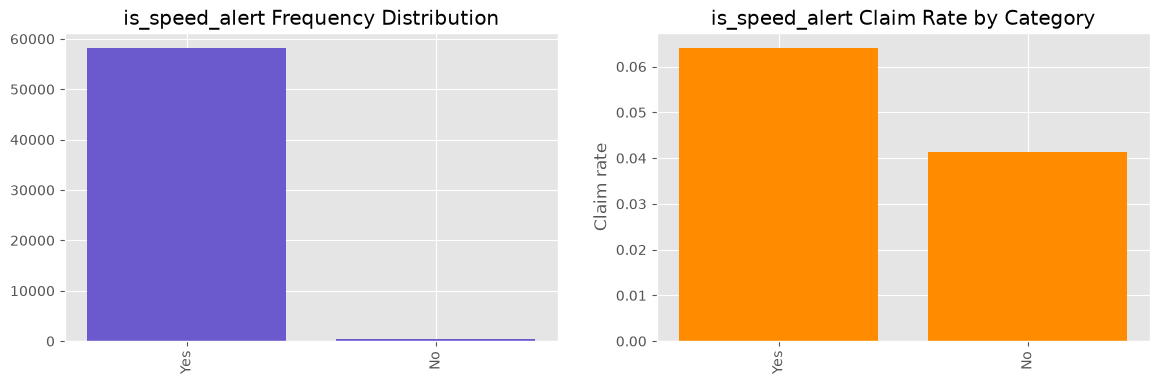

,category,count,percentage
0,Yes,58229,99.3805
1,No,363,0.6195


,is_speed_alert,claim_rate,row_count
0,Yes,0.064109,58229
1,No,0.041322,363


Interpretation for is_speed_alert: cardinality=2, dominant category share=99.38%, rare categories (<1% of rows)=1.


In [8]:
categorical_analysis_columns = da.CATEGORICAL_FEATURES + da.BINARY_FEATURES

for column in categorical_analysis_columns:
    frequency = da.category_frequency_table(train_df, column)
    claim_rates = da.claim_rate_by_category(train_df, column)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].bar(frequency['category'], frequency['count'], color='slateblue')
    axes[0].set_title(f'{column} Frequency Distribution')
    axes[0].set_xticklabels(frequency['category'], rotation=90)

    axes[1].bar(claim_rates[column], claim_rates['claim_rate'], color='darkorange')
    axes[1].set_title(f'{column} Claim Rate by Category')
    axes[1].set_xticklabels(claim_rates[column], rotation=90)
    axes[1].set_ylabel('Claim rate')
    plt.show()

    dominant_share = frequency['percentage'].iloc[0]
    rare_count = int((frequency['percentage'] < 1.0).sum())

    display(frequency)
    display(claim_rates)
    print(
        f"Interpretation for {column}: cardinality={len(frequency)}, dominant category share={dominant_share:.2f}%, "
        f"rare categories (<1% of rows)={rare_count}."
    )

### Categorical Summary Interpretation

- The categorical space is manageable: `area_cluster` has the highest cardinality among the audited high-level categories, while most other fields have modest cardinality.
- `make` is stored numerically but behaves as a categorical code and should not be interpreted as a continuous quantity.
- Several binary comfort or safety features have only modest univariate differences in claim rate, which suggests they may be more useful in combination with other features than in isolation.
- The official test set does not introduce unseen categories in the main audited categorical fields, which reduces near-term serving risk for Sprint 2 preprocessing design.


## Phase 6 - Relationship Analysis

C:\Users\97252\AppData\Local\Temp\ipykernel_13360\1435849385.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(binned_rates['bucket'], rotation=45, ha='right')


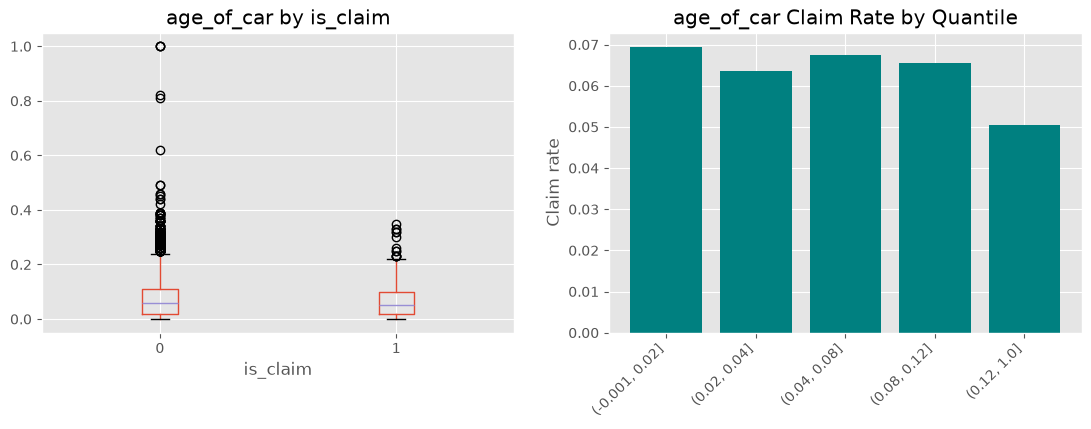

,bucket,claim_rate,row_count
0,"(-0.001, 0.02]",0.069431,16808
1,"(0.02, 0.04]",0.063585,8178
2,"(0.04, 0.08]",0.067593,12013
3,"(0.08, 0.12]",0.065428,10714
4,"(0.12, 1.0]",0.050372,10879


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\1435849385.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(binned_rates['bucket'], rotation=45, ha='right')


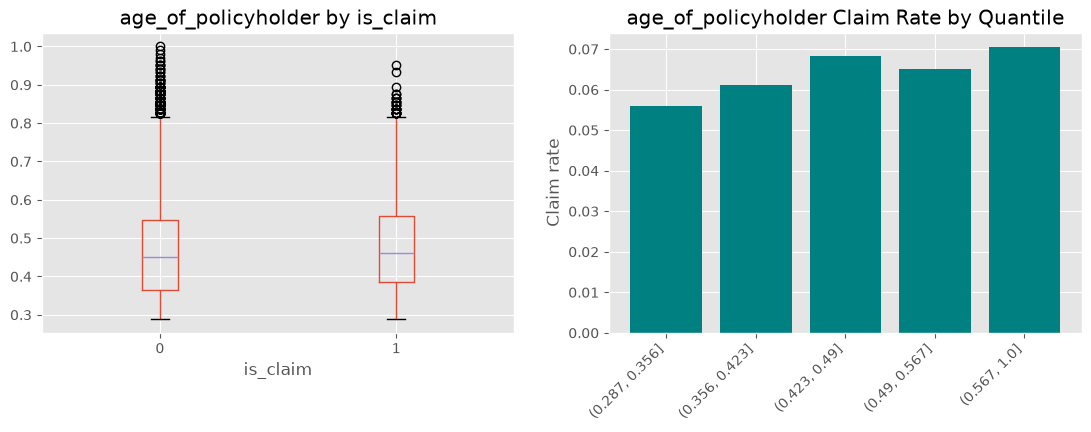

,bucket,claim_rate,row_count
0,"(0.287, 0.356]",0.055908,12932
1,"(0.356, 0.423]",0.061071,11855
2,"(0.423, 0.49]",0.068288,11598
3,"(0.49, 0.567]",0.065147,10530
4,"(0.567, 1.0]",0.070480,11677


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\1435849385.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(binned_rates['bucket'], rotation=45, ha='right')


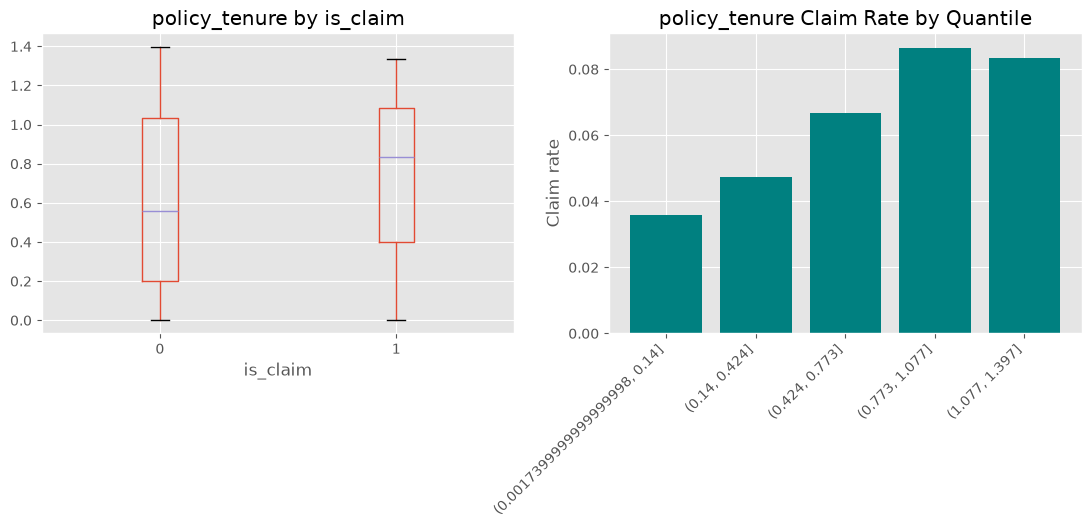

,bucket,claim_rate,row_count
0,"(0.0017399999999999998, 0.14]",0.035839,11719
1,"(0.14, 0.424]",0.047363,11718
2,"(0.424, 0.773]",0.066650,11718
3,"(0.773, 1.077]",0.086534,11718
4,"(1.077, 1.397]",0.083454,11719


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\1435849385.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(binned_rates['bucket'], rotation=45, ha='right')


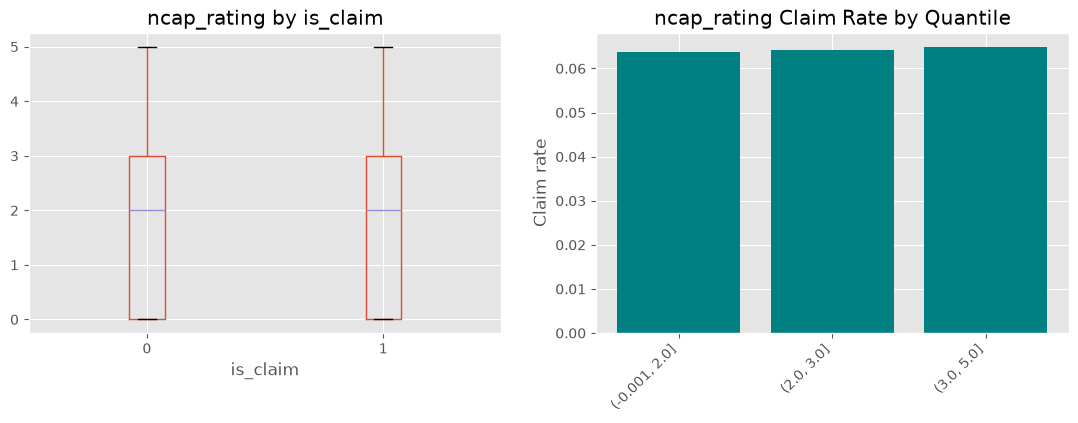

,bucket,claim_rate,row_count
0,"(-0.001, 2.0]",0.063779,40499
1,"(2.0, 3.0]",0.064275,14018
2,"(3.0, 5.0]",0.064785,4075


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\1435849385.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(binned_rates['bucket'], rotation=45, ha='right')


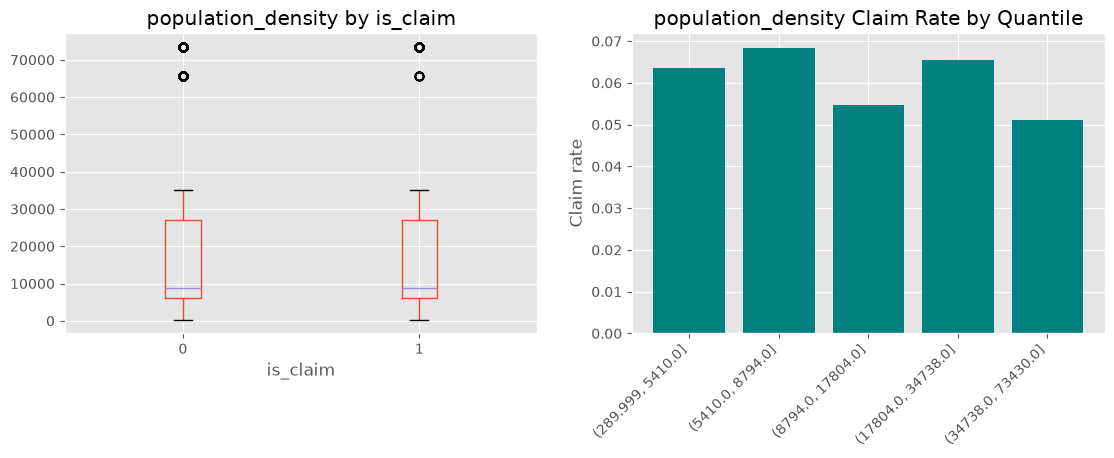

,bucket,claim_rate,row_count
0,"(289.999, 5410.0]",0.063499,12142
1,"(5410.0, 8794.0]",0.068429,20693
2,"(8794.0, 17804.0]",0.054584,4232
3,"(17804.0, 34738.0]",0.065433,16047
4,"(34738.0, 73430.0]",0.051114,5478


In [9]:
relationship_numeric_columns = ['age_of_car', 'age_of_policyholder', 'policy_tenure', 'ncap_rating', 'population_density']

for column in relationship_numeric_columns:
    binned_rates = da.claim_rate_by_quantile(train_df, column, quantiles=5)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    train_df.boxplot(column=column, by=da.TARGET_COLUMN, ax=axes[0])
    axes[0].set_title(f'{column} by is_claim')
    axes[0].figure.suptitle('')
    axes[0].set_xlabel('is_claim')

    axes[1].bar(binned_rates['bucket'], binned_rates['claim_rate'], color='teal')
    axes[1].set_title(f'{column} Claim Rate by Quantile')
    axes[1].set_ylabel('Claim rate')
    axes[1].set_xticklabels(binned_rates['bucket'], rotation=45, ha='right')
    plt.show()

    display(binned_rates)

C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3520628312.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(claim_rates[column], rotation=45, ha='right')


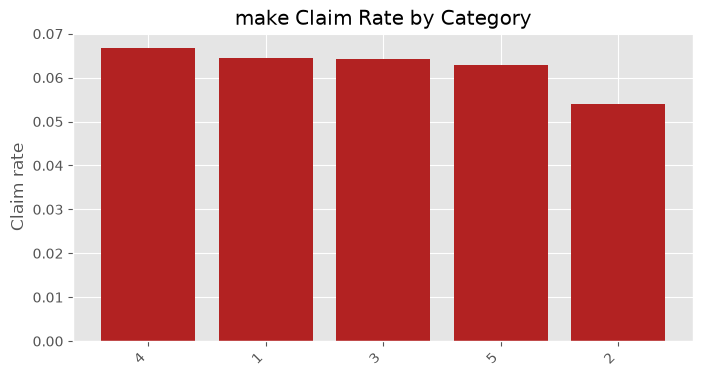

,make,claim_rate,row_count
0,4,0.066803,1961
1,1,0.064392,38126
2,3,0.064275,14018
3,5,0.062914,2114
4,2,0.053940,2373


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3520628312.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(claim_rates[column], rotation=45, ha='right')


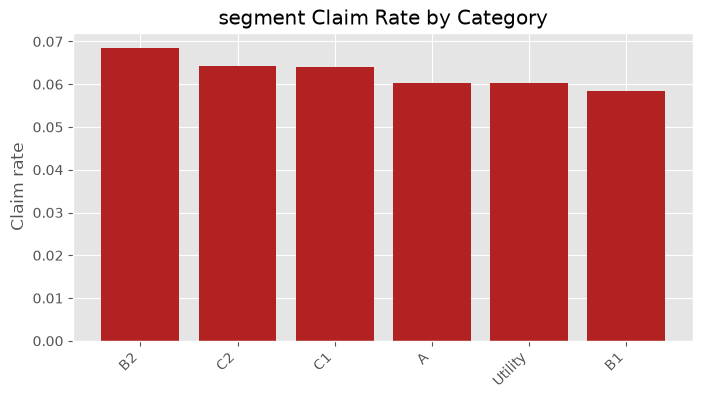

,segment,claim_rate,row_count
0,B2,0.068581,18314
1,C2,0.064275,14018
2,C1,0.064099,3557
3,A,0.060389,17321
4,Utility,0.060380,1209
5,B1,0.058471,4173


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3520628312.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(claim_rates[column], rotation=45, ha='right')


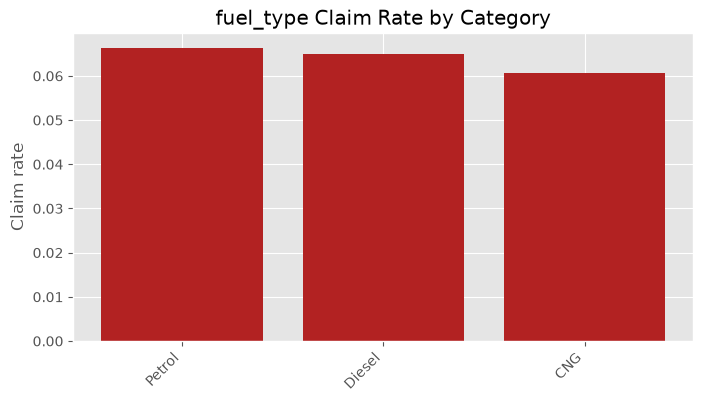

,fuel_type,claim_rate,row_count
0,Petrol,0.066384,20532
1,Diesel,0.064862,17730
2,CNG,0.060748,20330


C:\Users\97252\AppData\Local\Temp\ipykernel_13360\3520628312.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(claim_rates[column], rotation=45, ha='right')


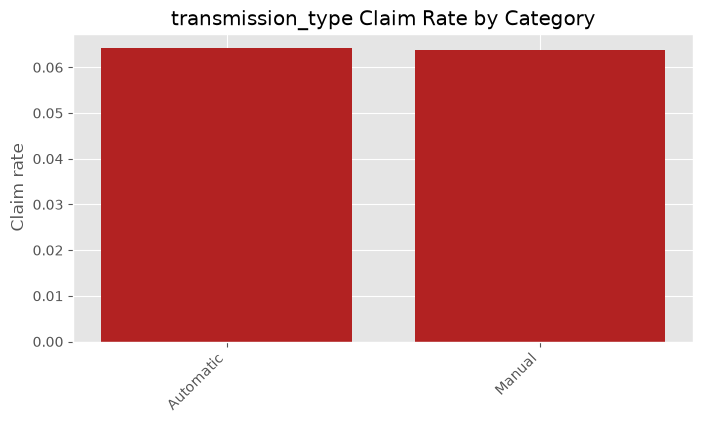

,transmission_type,claim_rate,row_count
0,Automatic,0.064181,20411
1,Manual,0.063854,38181


In [10]:
relationship_categorical_columns = ['make', 'segment', 'fuel_type', 'transmission_type']

for column in relationship_categorical_columns:
    claim_rates = da.claim_rate_by_category(train_df, column)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(claim_rates[column], claim_rates['claim_rate'], color='firebrick')
    ax.set_title(f'{column} Claim Rate by Category')
    ax.set_ylabel('Claim rate')
    ax.set_xticklabels(claim_rates[column], rotation=45, ha='right')
    plt.show()
    display(claim_rates)

### Relationship Findings

- `policy_tenure` shows the clearest monotonic pattern among the requested numeric features: claim rate rises from **3.58%** in the lowest tenure quintile to **8.65%** and **8.35%** in the top two quintiles.
- `age_of_policyholder` shows a milder upward pattern, from **5.59%** in the lowest quintile to **7.05%** in the highest.
- `age_of_car` is not monotonic: the oldest quintile has a lower claim rate (**5.04%**) than the youngest quintile (**6.94%**), which is a useful caution against naive assumptions.
- Among requested categorical fields, segment and model family show moderate variation, while transmission type looks almost neutral in univariate analysis.
- High-risk groups visible in raw rates include area cluster **C14** (**7.68%** with 3,660 rows) and model **M2** (**7.41%** with 1,080 rows).
- Lower-risk comparison groups include area cluster **C10** (**4.69%** with 3,155 rows) and model **M3** (**5.39%** with 2,373 rows).

These are descriptive patterns only. They are not causal findings.


## Phase 7 - Correlation & Feature Interaction Analysis

,policy_tenure,age_of_car,age_of_policyholder,population_density,airbags,displacement,cylinder,gear_box,turning_radius,length,width,height,gross_weight,ncap_rating,is_claim
policy_tenure,1.0000,0.1663,0.1437,-0.1003,0.1040,0.1944,0.1912,0.0953,0.1664,0.1909,0.2132,0.1191,0.1410,0.1733,0.0787
age_of_car,0.1663,1.0000,-0.0354,-0.0623,0.2091,0.3932,0.3795,0.2016,0.3327,0.3832,0.4141,0.2592,0.3021,0.3489,-0.0282
age_of_policyholder,0.1437,-0.0354,1.0000,0.0097,-0.0080,-0.0238,0.0042,-0.0031,-0.0168,-0.0201,-0.0061,-0.0539,-0.0078,-0.0316,0.0224
population_density,-0.1003,-0.0623,0.0097,1.0000,-0.0604,-0.0910,-0.0916,-0.0566,-0.0775,-0.0920,-0.0982,-0.0656,-0.0778,-0.0712,-0.0178
airbags,0.1040,0.2091,-0.0080,-0.0604,1.0000,0.6612,0.4786,0.8596,0.8108,0.8091,0.6396,0.4238,0.8290,0.3416,0.0028
displacement,0.1944,0.3932,-0.0238,-0.0910,0.6612,1.0000,0.8662,0.6922,0.8754,0.9617,0.8993,0.5546,0.7762,0.8471,0.0077
cylinder,0.1912,0.3795,0.0042,-0.0916,0.4786,0.8662,1.0000,0.4102,0.6158,0.8055,0.8624,0.3521,0.6030,0.5984,0.0134
gear_box,0.0953,0.2016,-0.0031,-0.0566,0.8596,0.6922,0.4102,1.0000,0.8617,0.8090,0.6019,0.5797,0.8946,0.5297,-0.0006
turning_radius,0.1664,0.3327,-0.0168,-0.0775,0.8108,0.8754,0.6158,0.8617,1.0000,0.9449,0.8256,0.4604,0.8231,0.7793,0.0027
length,0.1909,0.3832,-0.0201,-0.0920,0.8091,0.9617,0.8055,0.8090,0.9449,1.0000,0.9159,0.5536,0.8617,0.7675,0.0065


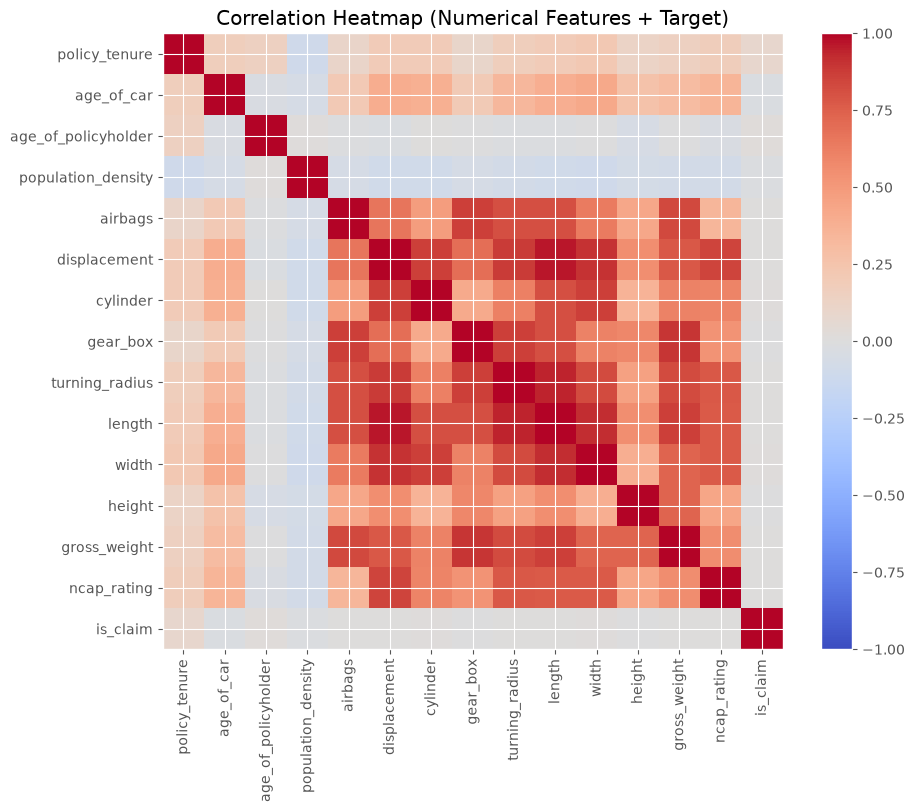

In [11]:
corr = da.correlation_matrix(train_df)
display(corr.round(4))

fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.imshow(corr, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title('Correlation Heatmap (Numerical Features + Target)')
plt.colorbar(heatmap, ax=ax)
plt.show()

policyholder_age_quintile,"(0.287, 0.356]","(0.356, 0.423]","(0.423, 0.49]","(0.49, 0.567]","(0.567, 1.0]"
tenure_quintile,,,,,
"(0.0017399999999999998, 0.14]",0.0350,0.0305,0.0378,0.0425,0.0351
"(0.14, 0.424]",0.0378,0.0479,0.0601,0.0415,0.0517
"(0.424, 0.773]",0.0630,0.0678,0.0716,0.0660,0.0650
"(0.773, 1.077]",0.0807,0.0880,0.0845,0.0904,0.0888
"(1.077, 1.397]",0.0773,0.0783,0.0869,0.0820,0.0893


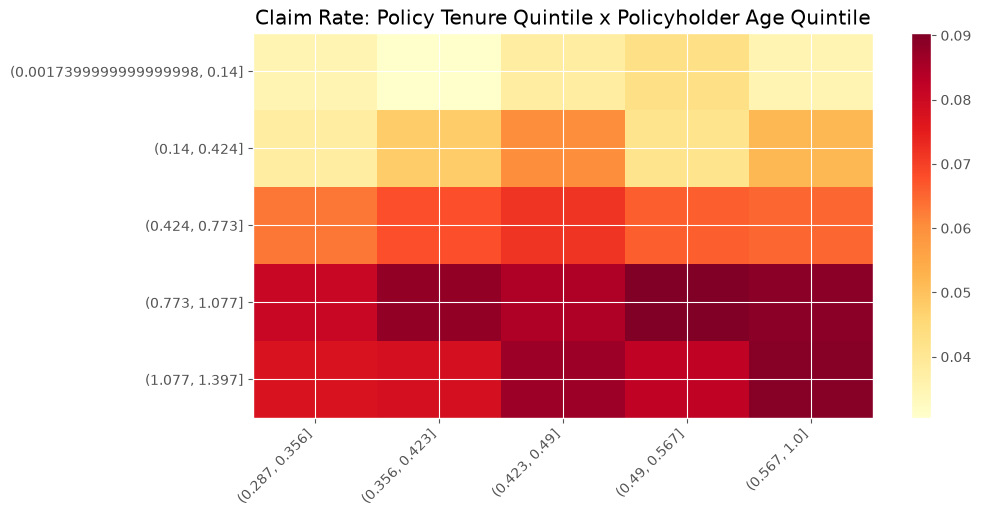

airbags,1,2,6
ncap_rating,,,
0,0.0604,0.0614,0.0684
2,NaN,0.0650,NaN
3,NaN,NaN,0.0643
4,NaN,0.0629,NaN
5,NaN,0.0668,NaN


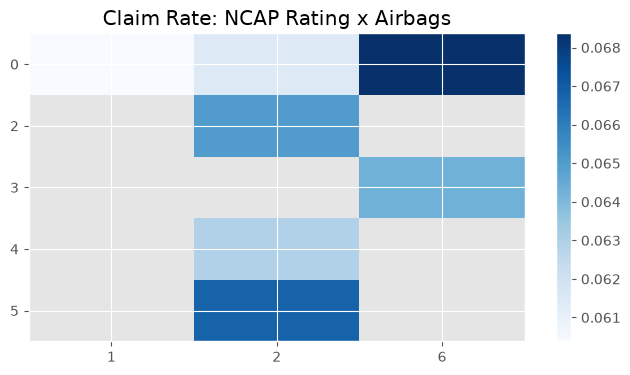

In [12]:
interaction_df = train_df.copy()
interaction_df['tenure_quintile'] = pd.qcut(interaction_df['policy_tenure'], q=5, duplicates='drop')
interaction_df['policyholder_age_quintile'] = pd.qcut(interaction_df['age_of_policyholder'], q=5, duplicates='drop')
interaction_pivot = interaction_df.pivot_table(
    values=da.TARGET_COLUMN,
    index='tenure_quintile',
    columns='policyholder_age_quintile',
    aggfunc='mean'
)

display(interaction_pivot.round(4))
fig, ax = plt.subplots(figsize=(10, 5))
heatmap = ax.imshow(interaction_pivot, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(interaction_pivot.columns)))
ax.set_xticklabels([str(col) for col in interaction_pivot.columns], rotation=45, ha='right')
ax.set_yticks(range(len(interaction_pivot.index)))
ax.set_yticklabels([str(idx) for idx in interaction_pivot.index])
ax.set_title('Claim Rate: Policy Tenure Quintile x Policyholder Age Quintile')
plt.colorbar(heatmap, ax=ax)
plt.show()

ncap_airbag_pivot = train_df.pivot_table(values=da.TARGET_COLUMN, index='ncap_rating', columns='airbags', aggfunc='mean')
display(ncap_airbag_pivot.round(4))
fig, ax = plt.subplots(figsize=(8, 4))
heatmap = ax.imshow(ncap_airbag_pivot, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(ncap_airbag_pivot.columns)))
ax.set_xticklabels(list(ncap_airbag_pivot.columns))
ax.set_yticks(range(len(ncap_airbag_pivot.index)))
ax.set_yticklabels(list(ncap_airbag_pivot.index))
ax.set_title('Claim Rate: NCAP Rating x Airbags')
plt.colorbar(heatmap, ax=ax)
plt.show()

### Correlation & Interaction Interpretation

- Linear correlations with `is_claim` are generally weak. The strongest positive one among the audited numeric fields is `policy_tenure` at approximately **0.0787**.
- `age_of_car` has a small negative linear correlation (**-0.0282**), and `population_density` is also weakly negative (**-0.0178**).
- The absence of strong single-feature correlations suggests that later modeling may benefit more from mixed-feature interactions than from relying on one dominant raw predictor.
- No obvious target leakage is visible from the Sprint 1 correlation review, but the raw torque/power strings and coded categorical variables still need careful treatment in Sprint 2.


## Phase 8 - Business Insights

### Observed higher-risk signals

- Longer policy tenure is associated with higher observed claim rates in the upper tenure quintiles.
- Some area clusters stand out materially above the portfolio average, especially **C14**.
- Certain model and engine families show elevated raw claim rates, including **M2** and its aligned engine family.
- Segment **B2** shows the highest claim rate among the major segment groups in the training data.

### Observed lower-risk signals

- Several area clusters sit below the portfolio average, especially **C10** among groups with at least 1,000 rows.
- Model **M3** and segment **B1** are on the lower end of the observed category claim-rate range.
- The oldest `age_of_car` quintile is not the riskiest group, which is a useful reminder that raw intuition does not always match observed portfolio behavior.

### Underwriting perspective

- Geographic cluster, tenure, and vehicle taxonomy look more promising as underwriting signals than single comfort-feature flags.
- Safety-count proxies such as airbags and NCAP rating do not show a strong standalone protective pattern in raw univariate analysis.
- These findings are descriptive only. They should guide later cleaning, transformation, and modeling work, not underwriting policy changes on their own.


## Phase 9 - Sprint Conclusion

### Dataset Assessment

- **Suitable for Machine Learning:** Yes. The dataset is large, structured, mixed-type, and internally consistent.
- **Suitable for Insurance Claim Prediction:** Yes. The target is explicitly claim occurrence, not a proxy label.
- **Suitable for Insurance Underwriting:** Yes, as a decision-support dataset. It contains policy, geography, vehicle, and equipment attributes that are relevant to underwriting workflows.

### Data Quality Assessment

- **Completeness:** Excellent - no missing values detected.
- **Consistency:** Good to excellent - no duplicate issues, no audited range violations, and no unexpected category drift between train and official test.
- **Modeling readiness:** Good, but not immediate. Sprint 2 still needs compound-string parsing, categorical treatment, and imbalance-aware preprocessing design.

### Recommendations for Sprint 2

- **Features requiring cleaning:** `max_torque`, `max_power` should be parsed into numeric parts.
- **Features requiring transformation:** skewed variables like `population_density` should be reviewed for scaling or transformation after the split.
- **Features requiring encoding:** coded categorical fields such as `area_cluster`, `make`, `segment`, `model`, `fuel_type`, `engine_type`, `steering_type`, plus binary string flags.
- **Features requiring engineering review:** power/torque-derived metrics and aggregated safety indicators are reasonable candidates, but they were intentionally not created in Sprint 1.

Sprint 1 ends here by design. No modeling or preprocessing starts in this notebook.
